# Benchmark de Visão Computacional — EuroSAT RGB

**CNN do zero + Optuna · ResNet50 · ViT + LightGBM · ViT + LoRA**

Este notebook é simultaneamente uma aula prática e o ponto de entrada executável do projeto. O percurso é:

> arquivo de imagem → pixels RGB → array NumPy → tensor PyTorch → filtros e convoluções → `Dataset`/`DataLoader` → quatro estratégias de modelagem → benchmark comum

Ao final, saberemos não apenas qual modelo obteve o maior **F1 Macro**, mas também quanto custou treiná-lo, quantos parâmetros foram adaptados e em quais classes ele errou.


## Como usar este notebook

1. Execute primeiro toda a **Parte I**; ela valida os dados e materializa um único split estratificado.
2. Na configuração, mantenha `EXECUTAR_TREINOS = False` para estudar o fluxo sem iniciar tarefas longas.
3. Quando o ambiente estiver pronto, altere a flag para `True` e execute os experimentos em ordem.
4. O teste só é consultado uma vez por modelo, depois de todas as decisões feitas com treino/validação.

Os blocos caros estão marcados com a tag `treino-pesado`. Em CPU, prefira `MODO_RAPIDO = True` para validar o pipeline antes da execução completa.


# Parte I — Fundamentos e exploração guiada

## 1. Apresentação, objetivos e mapa

**Pergunta de aprendizagem:** como números organizados em uma imagem se transformam em uma decisão de classe?

Objetivos:

- interpretar `H × W × C`, pixels, canais, `dtype` e faixa de valores;
- acompanhar `PIL → NumPy → Tensor`;
- entender kernels, feature maps, ativações e pooling;
- construir splits sem vazamento;
- distinguir aprendizado do zero, transfer learning, embeddings e LoRA.


### Mapa experimental

| Estratégia | Representação | O que é treinado |
|---|---|---|
| CNN do zero | filtros aprendidos no EuroSAT | toda a rede |
| ResNet50 | features ImageNet | cabeça e, opcionalmente, último bloco |
| ViT + LightGBM | embedding `[CLS]` congelado | somente LightGBM |
| ViT + LoRA | patches + self-attention | adaptadores LoRA e classificador |

**Conclusão da seção:** todos partem dos mesmos arquivos e índices; o que muda é como a representação visual é obtida e adaptada.


## 2. Problema de negócio e EuroSAT RGB

**Pergunta de aprendizagem:** qual decisão o modelo apoia e o que existe nos dados?

O EuroSAT RGB contém imagens aéreas de uso e cobertura do solo em dez classes. Um classificador pode apoiar triagem cartográfica e monitoramento territorial, mas não substitui validação geoespacial. Este escopo usa **somente RGB**; vermelho, verde e azul não devem ser confundidos com todas as bandas multiespectrais do Sentinel-2.

A unidade de análise é uma imagem e o alvo é uma das dez classes. Como errar uma classe rara importa tanto quanto errar uma frequente, o critério principal será **F1 Macro**.


## 3. Bibliotecas, ambiente, dispositivo e reprodutibilidade

**Objetivo:** carregar apenas dependências básicas no início e diagnosticar as opcionais antes dos experimentos.

PyTorch conduz os modelos; `transformers` fornece o ViT; `peft` aplica LoRA; LightGBM classifica embeddings; Optuna busca somente hiperparâmetros da CNN.


In [9]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Verificar se o kernel possui as dependências básicas do projeto.
# -----------------------------------------------------------------------------
# importlib permite verificar a presença de um pacote sem importá-lo por completo.
import importlib.util

# Estes pacotes são obrigatórios para executar a parte fundamental do notebook.
PACOTES_BASE = [
    "matplotlib",
    "numpy",
    "pandas",
    "PIL",
    "seaborn",
    "sklearn",
    "torch",
    "torchvision",
]
# find_spec retorna None quando o pacote não existe no ambiente do kernel.
ausentes_base = [p for p in PACOTES_BASE if importlib.util.find_spec(p) is None]

# Interrompemos cedo para evitar erros menos claros em células posteriores.
if ausentes_base:
    raise RuntimeError(
        "O kernel selecionado não possui as dependências básicas: "
        f"{ausentes_base}. Instale-as nesse ambiente ou selecione o kernel "
        "correto antes de continuar."
    )
print("Dependências básicas encontradas no kernel.")


Dependências básicas encontradas no kernel.


In [10]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Importar bibliotecas e configurar a apresentação de tabelas e gráficos.
# -----------------------------------------------------------------------------
# Adia a avaliação dos type hints e facilita referências a tipos definidos depois.
from __future__ import annotations

# Biblioteca padrão: arquivos, sistema, serialização, tempo e reprodutibilidade.
import copy
import hashlib
import importlib.util
import json
import os
import pickle
import platform
import random
import sys
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Callable, Iterable

# Bibliotecas para cálculo numérico, tabelas e visualizações.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# Scikit-learn fornece splits e métricas; PyTorch conduz o deep learning.
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
# PIL decodifica imagens; os imports seguintes organizam métricas e DataLoaders.
from PIL import Image, ImageFile
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.transforms import InterpolationMode

# Arquivos truncados devem gerar erro, pois imagens incompletas comprometem o dataset.
ImageFile.LOAD_TRUNCATED_IMAGES = False
# Define um estilo visual comum e permite visualizar mais colunas nas tabelas.
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


In [11]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Diagnosticar as dependências opcionais usadas nos experimentos avançados.
# -----------------------------------------------------------------------------
# Cada pacote abaixo é necessário apenas para uma etapa avançada específica.
PACOTES_OPCIONAIS = ["optuna", "lightgbm", "transformers", "peft", "safetensors"]
# A tabela torna explícito o que poderá ou não ser executado neste ambiente.
diagnostico = pd.DataFrame({
    "pacote": PACOTES_OPCIONAIS,
    "disponivel": [importlib.util.find_spec(p) is not None for p in PACOTES_OPCIONAIS],
})
# Exibe disponibilidade e versões para tornar a execução reproduzível.
display(diagnostico)
print(
    f"Python: {sys.version.split()[0]} | "
    f"PyTorch: {torch.__version__} | "
    f"torchvision: {torchvision.__version__}"
)
print(f"Sistema: {platform.platform()}")


,pacote,disponivel
0,optuna,True
1,lightgbm,True
2,transformers,True
3,peft,True
4,safetensors,True


Python: 3.10.19 | PyTorch: 2.6.0+cu126 | torchvision: 0.21.0+cu126
Sistema: Windows-10-10.0.19041-SP0


**Interpretação:** dependências opcionais ausentes afetam apenas seus respectivos experimentos. Instale-as no ambiente do kernel antes de ativar os treinos; não escondemos instalações dentro do notebook porque isso dificulta a reprodução.

**Conclusão da seção:** versões e disponibilidade ficam visíveis antes de consumir GPU ou baixar pesos.


## 4. Configurações e funções auxiliares

**Objetivo:** centralizar caminhos, semente e controles de custo. Nada abaixo deve depender do conjunto de teste para tomar decisões.


In [12]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Centralizar caminhos, semente, dispositivo e controles de execução.
# -----------------------------------------------------------------------------
@dataclass(frozen=True)
class Config:
    """Agrupa as configurações fixas e reproduzíveis do benchmark."""

    # Semente usada nas operações aleatórias: divisão dos dados, inicialização
    # dos pesos, embaralhamento dos lotes e amostragens.
    seed: int = 42

    # Altura e largura padronizadas das imagens. O valor 224 é compatível com
    # as entradas esperadas pela ResNet50 e pelo ViT escolhidos no projeto.
    img_size: int = 224

    # Frações reservadas para validação e teste. Os 70% restantes formam o
    # treino. Esses valores ficam fixos para todos os modelos do benchmark.
    val_size: float = 0.15
    test_size: float = 0.15

    # Quantidade de subprocessos usados pelo DataLoader. No Windows usamos 0
    # por padrão para evitar problemas de multiprocessamento em notebooks.
    num_workers: int = 0 if os.name == "nt" else 2

    # Limite máximo de épocas da CNN definitiva. O early stopping pode encerrar
    # o treinamento antes desse limite quando a validação deixa de melhorar.
    epochs: int = 30

    # Número de épocas consecutivas sem melhora toleradas pelo early stopping.
    patience: int = 6

    # Orçamento máximo de configurações que o Optuna testará na CNN.
    n_trials: int = 20

    # Identificador do ViT pré-treinado compartilhado pelos experimentos de
    # embeddings e LoRA, garantindo que ambos usem o mesmo backbone.
    vit_model_id: str = "google/vit-base-patch16-224-in21k"


# Cria uma única configuração. frozen=True evita que seus campos sejam
# alterados acidentalmente depois desta instanciação.
CFG = Config()

# Atalho para a semente, usado em várias funções ao longo do notebook.
SEED = CFG.seed

# Considera como raiz do projeto a pasta na qual o notebook foi iniciado e
# transforma o caminho em uma forma absoluta.
ROOT = Path.cwd().resolve()

# Centraliza os diretórios de entrada, modelos treinados e relatórios.
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "models"
REPORT_DIR = ROOT / "reports"

# Arquivo que guarda a divisão oficial dos dados. Incluir a semente no nome
# evita confundir splits criados com configurações aleatórias diferentes.
SPLIT_FILE = DATA_DIR / f"splits_eurosat_seed{SEED}.csv"

# True reduz dados, épocas e tentativas para testar rapidamente o pipeline.
MODO_RAPIDO = True

# False funciona como uma trava de segurança contra treinamentos demorados.
# Altere conscientemente para True quando quiser executar os experimentos.
EXECUTAR_TREINOS = False

# Seleciona a GPU CUDA quando disponível; caso contrário, utiliza a CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cria somente as pastas de saída. exist_ok=True evita erro se elas já existem.
for pasta in (ARTIFACT_DIR, REPORT_DIR):
    pasta.mkdir(parents=True, exist_ok=True)

# Exibe um resumo para confirmar os caminhos e o modo de execução antes de
# qualquer processamento ou treinamento.
print(f"Projeto: {ROOT}")
print(f"Dados: {DATA_DIR}")
print(f"Dispositivo: {DEVICE} | modo rápido: {MODO_RAPIDO} | treinos: {EXECUTAR_TREINOS}")


Projeto: D:\Projetos_v2\Modelo_VC_Satelites
Dados: D:\Projetos_v2\Modelo_VC_Satelites\data
Dispositivo: cuda | modo rápido: True | treinos: False


In [13]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Definir utilitários compartilhados pelas etapas do notebook.
# -----------------------------------------------------------------------------
# --- Reprodutibilidade -------------------------------------------------------
def definir_semente(seed: int = SEED) -> None:
    '''Reduz variação acidental entre execuções.'''
    # Cada biblioteca mantém seu próprio gerador de números aleatórios.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    # GPUs possuem geradores próprios; por isso também recebem a semente.
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Priorizamos repetibilidade em vez de escolher automaticamente o algoritmo mais rápido.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# --- Validação de dependências opcionais ------------------------------------
def exigir_pacote(nome: str) -> None:
    '''Produz erro acionável somente quando um experimento opcional é solicitado.'''
    if importlib.util.find_spec(nome) is None:
        raise ImportError(f"Instale '{nome}' no ambiente deste kernel para executar esta seção.")


# --- Sementes dos processos usados pelo DataLoader --------------------------
def worker_seed(worker_id: int) -> None:
    """Define uma semente diferente e reproduzível para cada worker."""
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)


# O gerador controla especificamente a ordem aleatória dos mini-batches.
def criar_gerador(seed: int = SEED) -> torch.Generator:
    """Cria o gerador usado pelo DataLoader para embaralhamento reproduzível."""
    return torch.Generator().manual_seed(seed)


# --- Conversão para visualização --------------------------------------------
def desnormalizar(
    tensor: torch.Tensor,
    media: Iterable[float],
    desvio: Iterable[float],
) -> torch.Tensor:
    """Retorna um tensor à escala visual aproximada de zero a um."""
    # [:, None, None] transforma três valores em (C, 1, 1) para broadcasting.
    media_t = torch.tensor(list(media), device=tensor.device)[:, None, None]
    desvio_t = torch.tensor(list(desvio), device=tensor.device)[:, None, None]
    return (tensor * desvio_t + media_t).clamp(0, 1)


# --- Medidas de custo do modelo ---------------------------------------------
def tamanho_modelo_mb(modelo: nn.Module) -> float:
    """Estima a memória ocupada por parâmetros e buffers do modelo."""
    # numel × bytes por elemento estima a memória ocupada por cada tensor.
    bytes_total = sum(p.numel() * p.element_size() for p in modelo.parameters())
    bytes_total += sum(b.numel() * b.element_size() for b in modelo.buffers())
    return bytes_total / 1024**2


# Separamos parâmetros totais dos que realmente receberão gradientes.
def contar_parametros(modelo: nn.Module) -> tuple[int, int]:
    """Conta parâmetros totais e parâmetros efetivamente treináveis."""
    total = sum(p.numel() for p in modelo.parameters())
    treinaveis = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    return total, treinaveis


# --- Inspeção didática de tensores ------------------------------------------
def resumo_tensor(nome: str, x: torch.Tensor | np.ndarray) -> None:
    """Mostra forma, tipo e faixa de valores de um array ou tensor."""
    print(f"{nome}: shape={tuple(x.shape)}, dtype={x.dtype}, min={x.min():.4f}, max={x.max():.4f}")


# --- Compatibilidade entre saídas PyTorch e Hugging Face --------------------
def logits_do_modelo(modelo: nn.Module, imagens: torch.Tensor) -> torch.Tensor:
    """Uniformiza a saída de modelos PyTorch e Hugging Face."""
    saida = modelo(imagens)
    return saida.logits if hasattr(saida, "logits") else saida


# --- Amostragem balanceada para o modo rápido -------------------------------
def subconjunto_rapido(df: pd.DataFrame, n_por_classe: int = 120) -> pd.DataFrame:
    """Seleciona uma amostra balanceada para validar o pipeline."""
    amostras_por_classe = []

    # Amostramos separadamente para nenhuma classe desaparecer do teste rápido.
    for _, grupo in df.groupby("classe"):
        quantidade = min(len(grupo), n_por_classe)
        amostras_por_classe.append(
            grupo.sample(
                n=quantidade,
                random_state=SEED,
            )
        )

    amostra_balanceada = pd.concat(
        amostras_por_classe,
        ignore_index=True,
    )
    return amostra_balanceada


# --- Registro padronizado do benchmark --------------------------------------
def registrar_resultado(
    nome: str,
    metricas: dict,
    treino_s: float,
    inferencia_s: float,
    modelo: nn.Module | None = None,
) -> None:
    """Adiciona métricas e custos ao registro consolidado."""
    # Modelos externos, como LightGBM, podem não ser instâncias de nn.Module.
    total, treinaveis, tamanho = np.nan, np.nan, np.nan
    if modelo is not None:
        total, treinaveis = contar_parametros(modelo)
        tamanho = tamanho_modelo_mb(modelo)

    RESULTADOS[nome] = {
        "modelo": nome,
        **metricas,
        "treino_s": treino_s,
        "inferencia_s": inferencia_s,
        "parametros_totais": total,
        "parametros_treinaveis": treinaveis,
        "tamanho_mb": tamanho,
    }


# --- Proteções contra vazamento entre os splits -----------------------------
def assert_splits_disjuntos(df: pd.DataFrame) -> None:
    """Confirma que nenhum caminho aparece em dois splits."""
    nomes_splits = ("treino", "validacao", "teste")
    grupos = {
        split: set(df.loc[df["split"].eq(split), "caminho_relativo"])
        for split in nomes_splits
    }
    # A interseção entre quaisquer dois conjuntos precisa ser vazia.
    assert not (grupos["treino"] & grupos["validacao"])
    assert not (grupos["treino"] & grupos["teste"])
    assert not (grupos["validacao"] & grupos["teste"])


# Uma assinatura muda se caminhos, classes, labels ou splits forem alterados.
def fingerprint_splits(df: pd.DataFrame) -> str:
    """Calcula uma assinatura curta e reproduzível dos splits."""
    colunas = ["caminho_relativo", "classe", "label", "split"]
    conteudo = (
        df[colunas]
        .sort_values("caminho_relativo")
        .to_csv(index=False)
        .encode("utf-8")
    )
    return hashlib.sha256(conteudo).hexdigest()[:16]


# --- Limpeza entre experimentos independentes ------------------------------
def limpar_memoria() -> None:
    """Libera o cache da GPU entre experimentos independentes."""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# Inicializa a sessão reproduzível e o dicionário que receberá os resultados.
definir_semente()
RESULTADOS: dict[str, dict] = {}


**Por que não importamos `src`?** Os módulos existentes em `src/` são utilitários de modelagem tabular e binária; forçá-los neste fluxo multiclasse de imagens criaria acoplamento incorreto. As rotinas visuais reutilizáveis permanecem autocontidas até serem estabilizadas e então poderão migrar para um módulo específico.

**Conclusão da seção:** caminhos e decisões experimentais estão em um único lugar, e a semente é aplicada também aos workers.


## 5. Leitura e inventário dos arquivos

**Pergunta de aprendizagem:** como comprovamos que as dez classes e os arquivos esperados realmente existem?


In [14]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Inventariar as imagens e criar o mapeamento entre classes e rótulos.
# -----------------------------------------------------------------------------
# Limitamos o inventário a extensões de imagem conhecidas.
EXTENSOES = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
# Falhar aqui produz uma mensagem mais clara do que um DataFrame vazio depois.
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Diretório não encontrado: {DATA_DIR}")

# Percorremos a estrutura esperada data/<classe>/<imagem>.
registros = []
for pasta_classe in sorted(p for p in DATA_DIR.iterdir() if p.is_dir()):
    for caminho in sorted(pasta_classe.iterdir()):
        if caminho.is_file() and caminho.suffix.lower() in EXTENSOES:
            registros.append({
                "caminho": caminho,
                "caminho_relativo": caminho.relative_to(ROOT).as_posix(),
                "classe": pasta_classe.name,
            })

# Uma tabela central passa a representar todo o inventário do dataset.
df_arquivos = pd.DataFrame(registros)
if df_arquivos.empty:
    raise RuntimeError(
        "Nenhuma imagem foi encontrada em data/<classe>/. "
        "Confira a extração do EuroSAT RGB."
    )

# A ordenação garante que o mesmo nome sempre receba o mesmo índice numérico.
CLASSES = sorted(df_arquivos["classe"].unique())
classe_para_id = {nome: i for i, nome in enumerate(CLASSES)}
df_arquivos["label"] = df_arquivos["classe"].map(classe_para_id)

# Contagem e proporção revelam classes ausentes ou desbalanceadas.
inventario = (df_arquivos.groupby("classe").size().rename("imagens").to_frame()
              .assign(proporcao=lambda x: x["imagens"] / x["imagens"].sum()))
display(inventario)
print(f"Total: {len(df_arquivos):,} | classes: {len(CLASSES)} | {CLASSES}")
assert len(CLASSES) == 10, f"Esperávamos 10 classes, encontramos {len(CLASSES)}."


,imagens,proporcao
classe,,
AnnualCrop,3000,0.111111
Forest,3000,0.111111
HerbaceousVegetation,3000,0.111111
Highway,2500,0.092593
Industrial,2500,0.092593
Pasture,2000,0.074074
PermanentCrop,2500,0.092593
Residential,3000,0.111111
River,2500,0.092593


Total: 27,000 | classes: 10 | ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


**Interpretação:** o inventário local deve totalizar 27.000 imagens. Diferenças pequenas ou grandes precisam ser explicadas antes do split; uma pasta ausente muda o problema.

**Conclusão da seção:** agora temos uma tabela explícita `arquivo → classe → label`, base de todas as etapas seguintes.


## 6. Da imagem ao array e ao tensor

**Pergunta de aprendizagem:** o que de fato entra em uma rede neural?

Um JPEG é um arquivo comprimido. A PIL o decodifica; o NumPy organiza intensidades em `(H, W, C)`; PyTorch usa `(C, H, W)`. Em lote, a convenção é `(N, C, H, W)`.

| Letra | Significado | Descrição |
|---|---|---|
| `N` | Number/Batch | Quantidade de imagens no lote |
| `C` | Channels | Quantidade de canais da imagem |
| `H` | Height | Altura da imagem em pixels |
| `W` | Width | Largura da imagem em pixels |

x.shape = (32, 3, 224, 224)

- 32 imagens no lote
- 3 canais por imagem: vermelho, verde e azul
- 224 pixels de altura
- 224 pixels de largura


In [15]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Converter uma imagem real de PIL para NumPy e depois para PyTorch.
# -----------------------------------------------------------------------------
# A semente mantém a mesma imagem didática entre execuções.
amostra = df_arquivos.sample(1, random_state=SEED).iloc[0]
# O gerenciador with fecha o arquivo assim que a cópia RGB é criada.
with Image.open(amostra["caminho"]) as img_aberta:
    imagem_pil = img_aberta.convert("RGB").copy()

# NumPy usa HWC e uint8; ToTensor reorganiza para CHW e converte para float.
imagem_np = np.asarray(imagem_pil)
imagem_tensor = transforms.ToTensor()(imagem_pil)

print(f"Arquivo: {amostra['caminho_relativo']} | classe: {amostra['classe']}")
print(f"PIL: size={imagem_pil.size}, mode={imagem_pil.mode}, format decodificado em RGB")
resumo_tensor("NumPy (H, W, C)", imagem_np)
resumo_tensor("PyTorch (C, H, W)", imagem_tensor)
print("Recorte NumPy [0:3, 0:3, :]:\n", imagem_np[:3, :3, :])


Arquivo: data/Forest/Forest_38.jpg | classe: Forest
PIL: size=(64, 64), mode=RGB, format decodificado em RGB
NumPy (H, W, C): shape=(64, 64, 3), dtype=uint8, min=25.0000, max=77.0000
PyTorch (C, H, W): shape=(3, 64, 64), dtype=torch.float32, min=0.0980, max=0.3020
Recorte NumPy [0:3, 0:3, :]:
 [[[31 58 65]
  [31 58 67]
  [30 54 64]]

 [[33 58 65]
  [33 58 65]
  [31 53 64]]

 [[32 55 63]
  [32 55 63]
  [32 55 63]]]


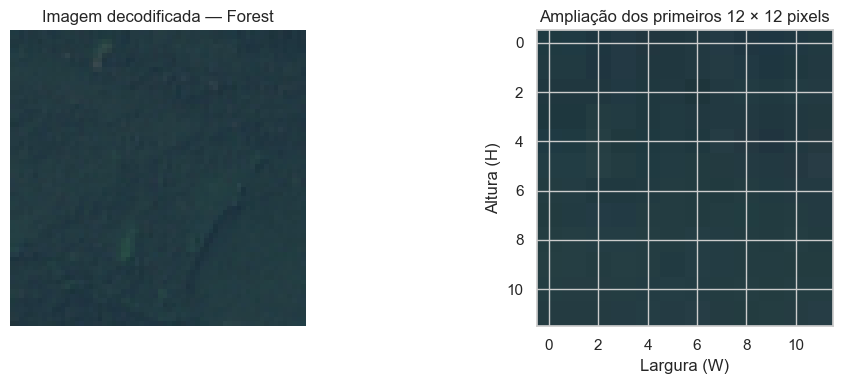

In [16]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Visualizar a imagem completa e ampliar uma pequena região de pixels.
# -----------------------------------------------------------------------------
# Colocamos a imagem completa e o recorte lado a lado para comparar escalas.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(imagem_pil)
axes[0].set_title(f"Imagem decodificada — {amostra['classe']}")
axes[0].axis("off")

# O recorte usa somente uma região pequena para que pixels individuais apareçam.
recorte = imagem_np[:12, :12]
axes[1].imshow(recorte)
axes[1].set_title("Ampliação dos primeiros 12 × 12 pixels")
axes[1].set_xlabel("Largura (W)")
axes[1].set_ylabel("Altura (H)")
plt.tight_layout()


### Checkpoint 1 e 2 — resposta

- `H × W × C` significa altura, largura e canais; cada pixel RGB guarda três intensidades.
- `uint8 [0,255] → float32 [0,1]` ocorre no `ToTensor`.
- o arquivo não entra diretamente na rede: entram números reorganizados de `(H,W,C)` para `(C,H,W)`.

**Conclusão da seção:** a imagem visual e o tensor são duas representações do mesmo conteúdo, com convenções e escalas diferentes.


## 7. Canais RGB, escala de cinza e visualização numérica

**Pergunta de aprendizagem:** que informação cada canal carrega e o que se perde ao reduzir para cinza?

#### Do espectro da luz até uma imagem RGB

A luz é uma forma de radiação eletromagnética. O espectro eletromagnético inclui diferentes regiões:

`Raios gama → Raios X → Ultravioleta → Luz visível → Infravermelho → Micro-ondas → Ondas de rádio`

O olho humano percebe apenas uma pequena parte desse espectro, chamada de **luz visível**, com comprimentos de onda aproximadamente entre 380 e 750 nanômetros.

##### Espectro aproximado das cores visíveis

| Cor percebida | Comprimento de onda aproximado |
|---|---:|
| Violeta | 380–450 nm |
| Azul | 450–495 nm |
| Verde | 495–570 nm |
| Amarelo | 570–590 nm |
| Laranja | 590–620 nm |
| Vermelho | 620–750 nm |

Essas divisões são aproximações. O espectro é contínuo: não existe uma fronteira física rígida entre azul, verde, amarelo ou vermelho.

##### Como o espectro se transforma em RGB?

Uma câmera ou sensor não armazena diretamente todas as cores do espectro. Em uma imagem RGB, a luz recebida é resumida em três medições:

- `R`: intensidade associada à região vermelha;
- `G`: intensidade associada à região verde;
- `B`: intensidade associada à região azul.

O processo pode ser resumido assim:

`Luz refletida pela superfície → sensor → filtros vermelho, verde e azul → valores digitais R, G e B → imagem`

Cada canal mede uma faixa de comprimentos de onda, e não uma única cor ou frequência exata. As três medições são combinadas para representar computacionalmente as cores percebidas.

Cores como amarelo e laranja não precisam de canais próprios. Elas são representadas pela combinação de RGB:

| Combinação aproximada | Cor resultante |
|---|---|
| Vermelho + verde | Amarelo |
| Vermelho + pouco verde | Laranja |
| Verde + azul | Ciano |
| Vermelho + azul | Magenta |
| Vermelho + verde + azul | Branco |
| Ausência dos três canais | Preto |

Esse processo é chamado de **síntese aditiva de cores**, pois aumentar as intensidades luminosas dos canais produz novas cores.

#### Como canais RGB e pixels funcionam

Uma imagem RGB possui três canais. Cada pixel é representado por:

`Pixel = [R, G, B]`

Em uma imagem de 8 bits, cada canal pode assumir 256 valores:

`0 a 255`

Isso acontece porque:

\[
2^8 = 256
\]

A interpretação geral é:

- `0`: menor intensidade digital daquele canal;
- `255`: maior intensidade digital daquele canal.

Exemplos:

| RGB | Cor resultante |
|---|---|
| `[255, 0, 0]` | Vermelho |
| `[0, 255, 0]` | Verde |
| `[0, 0, 255]` | Azul |
| `[255, 255, 0]` | Amarelo |
| `[0, 255, 255]` | Ciano |
| `[255, 0, 255]` | Magenta |
| `[255, 255, 255]` | Branco |
| `[0, 0, 0]` | Preto |
| `[128, 128, 128]` | Cinza |

Na imagem `Forest_38.jpg`, um dos pixels possui:

`[31, 58, 65]`

Isso significa:

- vermelho com intensidade digital 31;
- verde com intensidade digital 58;
- azul com intensidade digital 65.

A combinação produz um tom escuro com predominância azul-esverdeada.

#### Os valores RGB possuem unidade física?

Os valores entre 0 e 255 são **níveis digitais**, também chamados de *Digital Numbers*. Eles não possuem uma unidade física direta.

Por exemplo, o valor `65` não significa:

- 65% de luz;
- 65 fótons;
- 65 watts.

Ele significa apenas que, depois da captura e do processamento, aquele canal recebeu o nível digital 65.

Quando usamos `ToTensor()`, o PyTorch divide esses valores por 255:

$$x_{normalizado}=\frac{x_{uint8}}{255}$$

Assim:

`uint8 [0,255] → float32 [0,1]`

Para o pixel `[31, 58, 65]`, temos aproximadamente:

`[0,122; 0,227; 0,255]`

A escala muda, mas a proporção entre os canais é preservada.

#### Relação com imagens de satélite

Materiais diferentes absorvem e refletem partes diferentes do espectro. A vegetação, por exemplo, costuma absorver bastante luz vermelha e refletir relativamente mais verde. Atmosfera, sombras, iluminação, resposta do sensor e processamento também influenciam os valores registrados.

Uma imagem RGB comum representa somente a região visível. Ela não contém diretamente informações de micro-ondas, raios gama ou infravermelho.

Satélites multiespectrais podem registrar outras bandas, como:

- azul;
- verde;
- vermelho;
- red edge;
- infravermelho próximo;
- infravermelho de ondas curtas.

No EuroSAT RGB utilizado neste projeto, trabalhamos somente com três canais visíveis:

`C = 3 → vermelho, verde e azul`

Portanto, RGB possui duas dimensões complementares:

- **origem física:** luz visível refletida pela superfície e medida pelo sensor;
- **representação computacional:** três matrizes numéricas combinadas para formar as cores da imagem.


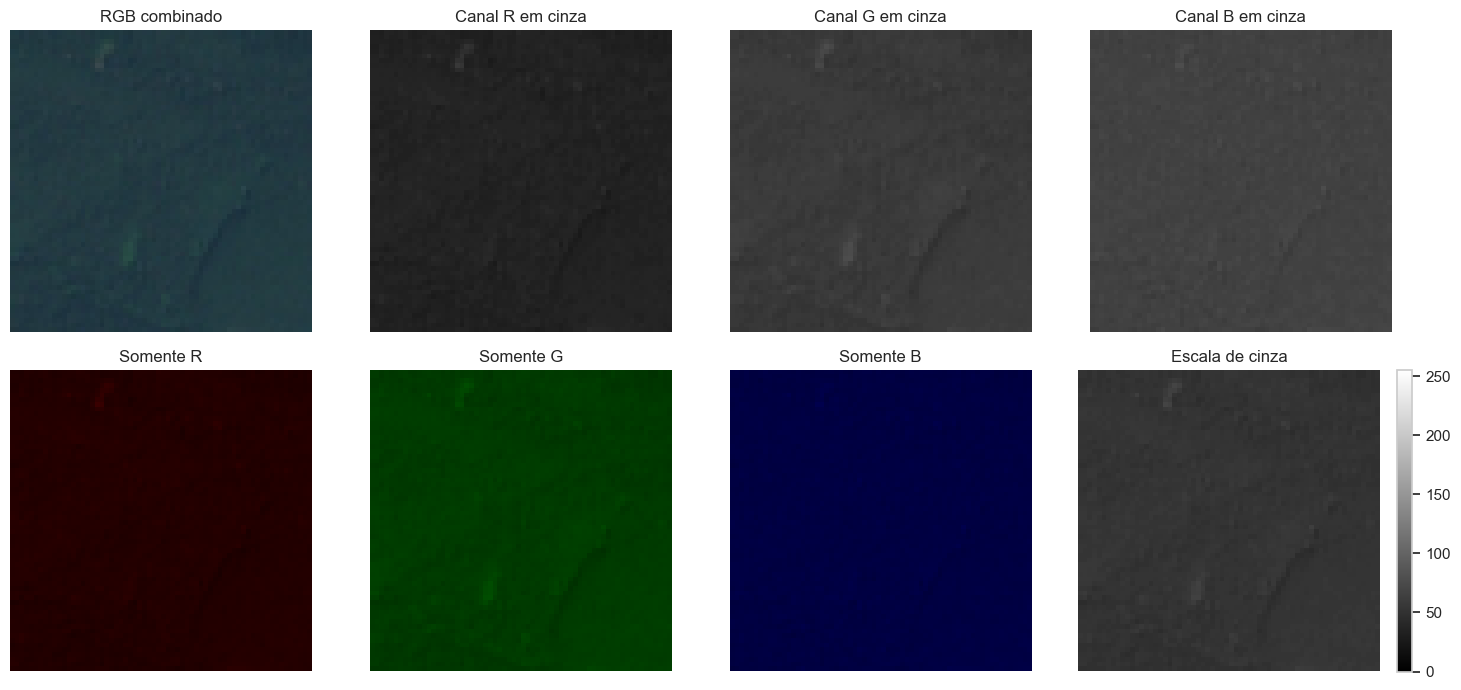

In [17]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Separar os canais RGB e comparar a informação visual de cada canal.
# -----------------------------------------------------------------------------
# A grade compara RGB, canais em cinza, canais coloridos e escala de cinza.
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes[0, 0].imshow(imagem_np)
axes[0, 0].set_title("RGB combinado")
axes[0, 0].axis("off")

# Cada posição da última dimensão corresponde a R, G ou B.
cores = [(1, 0, 0), (0, 1, 0), (0, 0, 1)]
nomes = ["R", "G", "B"]
# Para cada canal, mostramos intensidades e uma imagem com as outras cores zeradas.
for i, (nome, cor) in enumerate(zip(nomes, cores)):
    canal = imagem_np[:, :, i]
    axes[0, i + 1].imshow(canal, cmap="gray", vmin=0, vmax=255)
    axes[0, i + 1].set_title(f"Canal {nome} em cinza")
    axes[0, i + 1].axis("off")
    isolada = np.zeros_like(imagem_np)
    isolada[:, :, i] = canal
    axes[1, i].imshow(isolada)
    axes[1, i].set_title(f"Somente {nome}")
    axes[1, i].axis("off")

# A conversão L combina RGB em uma única intensidade luminosa.
cinza = np.asarray(imagem_pil.convert("L"))
im = axes[1, 3].imshow(cinza, cmap="gray", vmin=0, vmax=255)
axes[1, 3].set_title("Escala de cinza")
axes[1, 3].axis("off")
fig.colorbar(im, ax=axes[1, 3], fraction=0.046)
plt.tight_layout()


,linha,coluna,RGB
0,0,0,"[31, 58, 65]"
1,32,32,"[38, 63, 68]"
2,-1,-1,"[33, 62, 70]"


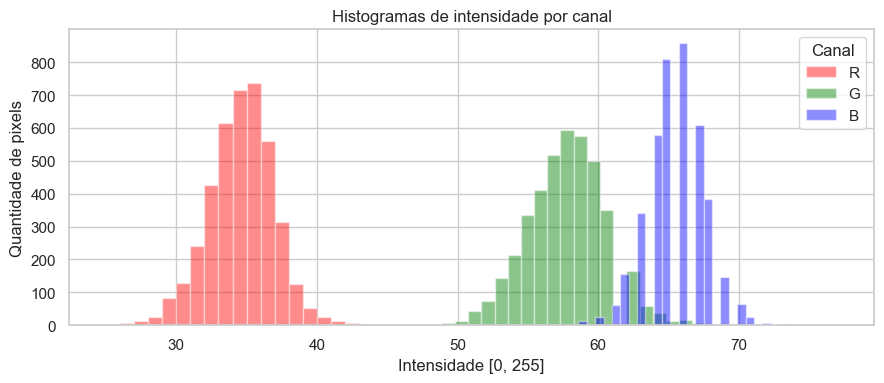

In [18]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Comparar histogramas RGB e inspecionar valores de pixels específicos.
# -----------------------------------------------------------------------------
# Histogramas mostram como as intensidades se distribuem em cada canal.
plt.figure(figsize=(9, 4))
for i, (nome, cor) in enumerate(zip(nomes, ["red", "green", "blue"])):
    plt.hist(imagem_np[:, :, i].ravel(), bins=32, alpha=0.45, color=cor, label=nome)
plt.title("Histogramas de intensidade por canal")
plt.xlabel("Intensidade [0, 255]")
plt.ylabel("Quantidade de pixels")
plt.legend(title="Canal")
plt.tight_layout()

# Inspecionamos o primeiro pixel, o pixel central e o último pixel.
pontos = [(0, 0), (imagem_np.shape[0] // 2, imagem_np.shape[1] // 2), (-1, -1)]
pixels_selecionados = [
    {"linha": y, "coluna": x, "RGB": imagem_np[y, x].tolist()}
    for y, x in pontos
]
display(pd.DataFrame(pixels_selecionados))


**Interpretação:** diferenças entre histogramas indicam como cada faixa visível participa da cena. A conversão para cinza combina canais e elimina distinções cromáticas potencialmente úteis. Isso ainda não representa bandas multiespectrais.

**Conclusão da seção:** RGB preserva três medições visíveis por pixel; cinza reduz informação para uma intensidade.


## 8. Transformações geométricas, interpolação e normalização

**Pergunta de aprendizagem:** por que padronizar tamanho e escala, e como fazer isso sem confundir visualização com entrada do modelo?

#### Redimensionamento e interpolação

A transformação de uma imagem de `64 × 64` para `224 × 224` é chamada de **redimensionamento** (*resize*).

Como estamos aumentando a imagem, também podemos chamar essa operação de **upsampling**.

```text
Imagem original:       64 × 64
Imagem redimensionada: 224 × 224
```

O fator de aumento em cada dimensão é:

$\frac{224}{64}=3{,}5$

A imagem original não possui valores para todas as novas posições da grade 224 × 224. O algoritmo precisa estimá-los usando os pixels existentes. A **interpolação** é o método utilizado durante o redimensionamento para estimar os valores dos novos pixels.

No notebook, utilizamos:

```python
transforms.Resize(
    (224, 224),
    interpolation=InterpolationMode.BILINEAR,
)
```

Isso significa:

```text
Resize   → operação de alterar o tamanho
Bilinear → método usado para calcular os novos pixels
```

##### Principais métodos de interpolação

- **Nearest neighbor:** copia o valor do pixel original mais próximo. É rápido, mas pode produzir blocos.
- **Bilinear:** combina os quatro pixels vizinhos mais próximos, produzindo transições mais suaves.
- **Bicubic:** considera uma vizinhança maior e pode gerar resultados ainda mais suaves.

É importante lembrar que aumentar a imagem não cria novos detalhes reais:

```text
64 × 64   = 4.096 pixels originais
224 × 224 = 50.176 posições após o resize
```

Os novos valores são estimados a partir dos pixels originais. O redimensionamento é necessário porque modelos como ResNet50 e ViT normalmente esperam imagens de entrada com `224 × 224` pixels.


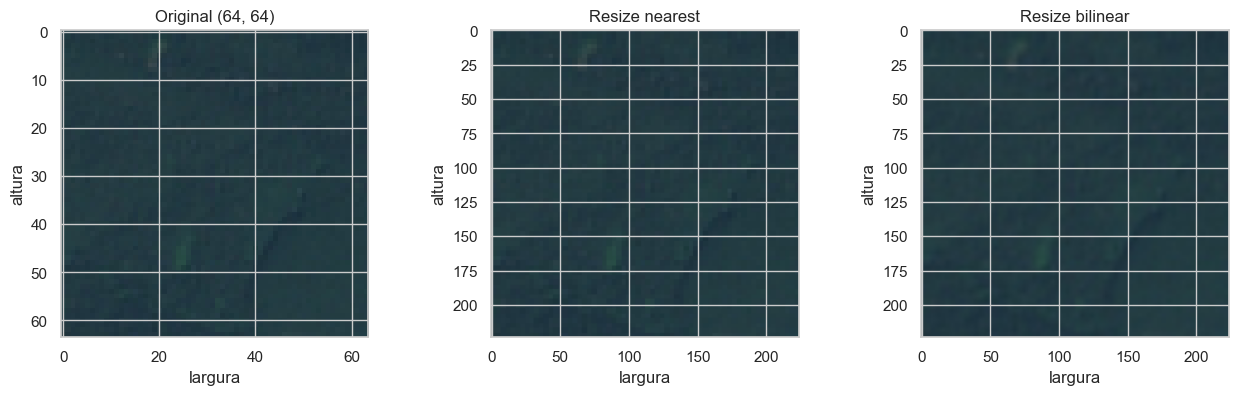

In [19]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Comparar os métodos nearest e bilinear durante o redimensionamento.
# -----------------------------------------------------------------------------
# Nearest copia o vizinho mais próximo; bilinear interpola quatro vizinhos.
resize_nearest = transforms.Resize(
    (CFG.img_size, CFG.img_size),
    interpolation=InterpolationMode.NEAREST,
)
resize_bilinear = transforms.Resize(
    (CFG.img_size, CFG.img_size),
    interpolation=InterpolationMode.BILINEAR,
)

# Aplicamos os dois métodos à mesma imagem para uma comparação justa.
t_nearest = resize_nearest(imagem_pil)
t_bilinear = resize_bilinear(imagem_pil)

# A grade mantém original e resultados lado a lado.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, img, titulo in zip(
    axes, [imagem_pil, t_nearest, t_bilinear],
    [f"Original {imagem_pil.size}", "Resize nearest", "Resize bilinear"],
):
    ax.imshow(img)
    ax.set_title(titulo)
    ax.set_xlabel("largura")
    ax.set_ylabel("altura")
plt.tight_layout()


Antes da normalização: shape=(3, 224, 224), dtype=torch.float32, min=0.0980, max=0.3020
Depois da normalização: shape=(3, 224, 224), dtype=torch.float32, min=-1.6898, max=-0.4624


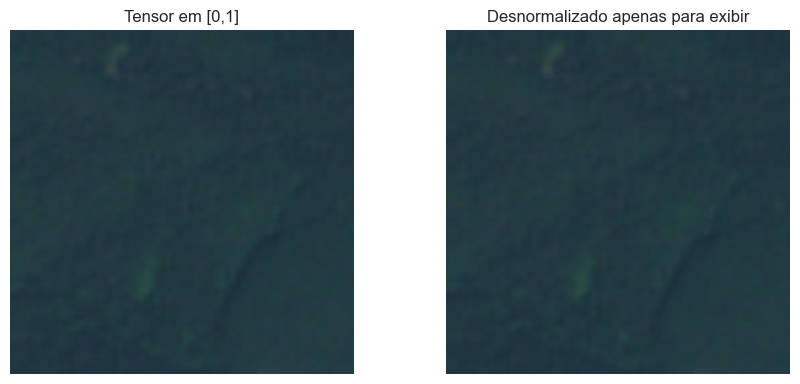

In [20]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Normalizar o tensor e desfazer a normalização somente para visualização.
# -----------------------------------------------------------------------------
# Estatísticas da ImageNet esperadas pelos pesos pré-treinados usados depois.
MEAN_IMAGENET = (0.485, 0.456, 0.406)
STD_IMAGENET = (0.229, 0.224, 0.225)
to_tensor = transforms.ToTensor()
normalizar = transforms.Normalize(MEAN_IMAGENET, STD_IMAGENET)

# Primeiro convertemos para [0,1]; depois centralizamos e escalamos cada canal.
x_01 = to_tensor(t_bilinear)
x_norm = normalizar(x_01)
resumo_tensor("Antes da normalização", x_01)
resumo_tensor("Depois da normalização", x_norm)

# A normalização é desfeita apenas na cópia usada para visualização.
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(x_01.permute(1, 2, 0))
axes[0].set_title("Tensor em [0,1]")
axes[1].imshow(desnormalizar(x_norm, MEAN_IMAGENET, STD_IMAGENET).permute(1, 2, 0))
axes[1].set_title("Desnormalizado apenas para exibir")
for ax in axes:
    ax.axis("off")
plt.tight_layout()


**Interpretação:** resize altera a grade espacial, não o rótulo. Nearest preserva blocos; bilinear suaviza a interpolação. Normalização pode produzir valores negativos e acima de 1 — isso é esperado. Desnormalizamos somente para plotar.

**Conclusão da seção:** modelos exigem dimensões previsíveis e a normalização esperada pelos pesos pré-treinados.


## 9. Filtros clássicos e convolução passo a passo

**Pergunta de aprendizagem:** como um kernel local produz um mapa de características?

Para entrada de tamanho `H×W`, kernel `K`, padding `P` e stride `S`, a saída por eixo é `floor((H + 2P - K)/S) + 1`.

### Como o kernel produz um mapa de características

A convolução aplica um pequeno filtro, chamado **kernel**, sobre diferentes regiões da imagem. Em cada posição, os valores da janela são multiplicados pelos pesos do kernel e depois somados.

Neste exemplo, usamos uma janela `3 × 3`:

```text
[[0.200, 0.200, 0.188],
 [0.200, 0.200, 0.188],
 [0.192, 0.192, 0.192]]
```

e um kernel Sobel vertical:

```text
[[-1, 0, 1],
 [-2, 0, 2],
 [-1, 0, 1]]
```

Esse kernel compara aproximadamente o lado direito com o lado esquerdo da janela, procurando mudanças horizontais de intensidade que indicam bordas verticais.

#### Multiplicação elemento a elemento

```text
Janela                 Kernel               Produto

 0.200  0.200  0.188    -1  0  1          -0.200  0  0.188
 0.200  0.200  0.188 ×  -2  0  2    =     -0.400  0  0.376
 0.192  0.192  0.192    -1  0  1          -0.192  0  0.192
```

Somando os produtos:


$$(-0{,}200+0{,}188)+(-0{,}400+0{,}376)+(-0{,}192+0{,}192)
=-0{,}035294$$

Esse resultado corresponde a uma única ativação do mapa de características.

#### Interpretação da ativação

- valor positivo: a intensidade aumenta da esquerda para a direita;
- valor negativo: a intensidade diminui da esquerda para a direita;
- valor próximo de zero: pouca diferença entre os lados;
- grande valor absoluto: presença de uma borda mais intensa.

Como o resultado foi `-0,035294`, existe uma pequena redução de intensidade da esquerda para a direita, indicando uma borda fraca.

#### Formação do mapa de características

O kernel desliza sobre toda a entrada, produzindo uma ativação em cada posição.

Para:

```text
Entrada:  7 × 7
Kernel:   3 × 3
Stride:   1
Padding:  0
```

o tamanho da saída é:


$$\left\lfloor\frac{7+2(0)-3}{1}\right\rfloor+1=5$$

Portanto:

```text
Entrada 7 × 7
      ↓ kernel aplicado em 25 posições
Mapa de características 5 × 5
```

No exemplo, o kernel Sobel foi definido manualmente. Em uma CNN, os valores dos kernels são aprendidos por backpropagation.

```text
Filtro clássico → pesos definidos manualmente
CNN             → pesos aprendidos durante o treinamento
```

Uma camada também pode utilizar vários filtros:

```text
1 filtro    → 1 feature map
32 filtros → 32 feature maps
```

Assim, diferentes filtros podem aprender a identificar bordas, cores, texturas, formas e padrões mais abstratos.


In [21]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Implementar manualmente a convolução para observar cada operação.
# -----------------------------------------------------------------------------
# Esta implementação explícita prioriza entendimento, não desempenho.
def convolucao_2d_manual(entrada: np.ndarray, kernel: np.ndarray,
                         stride: int = 1, padding: int = 0) -> np.ndarray:
    '''Convolução 2D didática, sem rotação do kernel (correlação cruzada).'''
    # Padding adiciona uma borda de zeros antes de deslizar o kernel.
    entrada_pad = np.pad(entrada, padding, mode="constant")
    kh, kw = kernel.shape
    # Calculamos previamente as dimensões espaciais do mapa de saída.
    oh = (entrada_pad.shape[0] - kh) // stride + 1
    ow = (entrada_pad.shape[1] - kw) // stride + 1
    saida = np.zeros((oh, ow), dtype=np.float32)
    # Cada posição multiplica uma janela local pelo kernel e soma os produtos.
    for i in range(oh):
        for j in range(ow):
            janela = entrada_pad[i * stride:i * stride + kh, j * stride:j * stride + kw]
            saida[i, j] = np.sum(janela * kernel)
    return saida


# Usamos um recorte pequeno e normalizado para visualizar a conta completa.
janela = cinza[:7, :7].astype(np.float32) / 255
sobel_vertical = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
produto = janela[:3, :3] * sobel_vertical
print("Janela 3×3:\n", np.round(janela[:3, :3], 3))
print("Kernel:\n", sobel_vertical)
print("Produto elemento a elemento:\n", np.round(produto, 3))
print("Soma / primeira ativação:", produto.sum())
display(pd.DataFrame(convolucao_2d_manual(janela, sobel_vertical)))


Janela 3×3:
 [[0.2   0.2   0.188]
 [0.2   0.2   0.188]
 [0.192 0.192 0.192]]
Kernel:
 [[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]
Produto elemento a elemento:
 [[-0.2    0.     0.188]
 [-0.4    0.     0.376]
 [-0.192  0.     0.192]]
Soma / primeira ativação: -0.035294116


,0,1,2,3,4
0,-0.035294,0.019608,0.011765,-0.039216,0.015686
1,0.007843,0.035294,-0.011765,-0.023529,-0.003922
2,0.054902,0.035294,-0.050980,-0.007843,-0.003922
3,0.058824,0.003922,-0.074510,0.000000,0.000000
4,0.019608,-0.023529,-0.054902,0.007843,0.007843


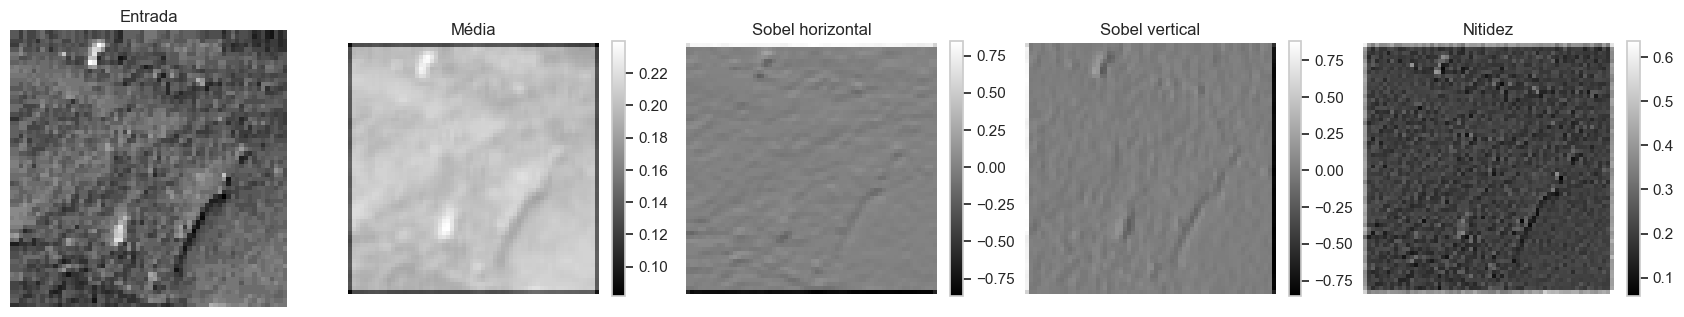

In [22]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Aplicar filtros clássicos e comparar seus mapas de características.
# -----------------------------------------------------------------------------
# Cada kernel enfatiza um tipo diferente de padrão local.
cinza_01 = cinza.astype(np.float32) / 255
kernels = {
    "Média": np.ones((3, 3), dtype=np.float32) / 9,
    "Sobel horizontal": np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32),
    "Sobel vertical": sobel_vertical,
    "Nitidez": np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32),
}
# A entrada ocupa o primeiro eixo; os quatro mapas ocupam os seguintes.
fig, axes = plt.subplots(1, 5, figsize=(17, 4))
axes[0].imshow(cinza_01, cmap="gray")
axes[0].set_title("Entrada")
axes[0].axis("off")
# Padding 1 preserva altura e largura para kernels 3 × 3 com stride 1.
for ax, (nome, kernel) in zip(axes[1:], kernels.items()):
    mapa = convolucao_2d_manual(cinza_01, kernel, padding=1)
    im = ax.imshow(mapa, cmap="gray")
    ax.set_title(nome)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()


In [23]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Reproduzir o filtro manual com uma camada Conv2d do PyTorch.
# -----------------------------------------------------------------------------
# As duas dimensões adicionadas representam batch N e canal C: (1,1,H,W).
x_gray = torch.from_numpy(cinza_01)[None, None]
conv = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=1, bias=False)
# Copiamos o Sobel para a camada e desativamos gradientes nesta demonstração.
with torch.no_grad():
    conv.weight.copy_(torch.from_numpy(sobel_vertical)[None, None])
    y_conv = conv(x_gray)

# allclose confirma numericamente que as duas implementações são equivalentes.
print("Entrada NCHW:", tuple(x_gray.shape), "→ saída NCHW:", tuple(y_conv.shape))
print("Saídas manual e PyTorch próximas:", np.allclose(
    convolucao_2d_manual(cinza_01, sobel_vertical, padding=1), y_conv[0, 0].numpy(), atol=1e-5
))


Entrada NCHW: (1, 1, 64, 64) → saída NCHW: (1, 1, 64, 64)
Saídas manual e PyTorch próximas: True


### Checkpoint 3 — resposta

- kernel define a vizinhança; stride define o salto; padding controla bordas e tamanho;
- um filtro gera um feature map; vários filtros geram vários canais de saída;
- filtros clássicos são fixos, enquanto `Conv2d` aprende os pesos por backpropagation.

**Conclusão da seção:** convolução transforma padrões locais em mapas que realçam propriedades úteis.


## 10. Ativação, pooling, feature maps e data augmentation

**Pergunta de aprendizagem:** como a rede reduz a dimensão e ganha diversidade sem alterar o significado da classe?

### Ativação, pooling, feature maps e data augmentation

Esta demonstração mostra como a ReLU modifica as ativações e como o Max Pooling reduz as dimensões espaciais de um feature map.

A entrada possui formato:

```text
(N, C, H, W) = (1, 1, 4, 4)
```

Isso significa:

- `N = 1`: uma amostra no batch;
- `C = 1`: um feature map ou canal;
- `H = 4`: quatro linhas;
- `W = 4`: quatro colunas.

A matriz de entrada é:

```text
[[-2,  1,  0,  3],
 [ 4, -1,  2,  0],
 [ 1,  5, -3,  2],
 [ 0,  2,  1,  4]]
```

#### Aplicação da ReLU

A função ReLU é definida por:


$$ReLU(x)=\max(0,x)$$

Ela mantém valores positivos e substitui valores negativos por zero:

```text
Entrada negativa → 0
Entrada positiva → permanece igual
```

Resultado:

```text
[[0, 1, 0, 3],
 [4, 0, 2, 0],
 [1, 5, 0, 2],
 [0, 2, 1, 4]]
```

O formato permanece igual:

```text
Antes da ReLU:  (1, 1, 4, 4)
Depois da ReLU: (1, 1, 4, 4)
```

A ReLU não reduz a imagem. Sua função é introduzir não linearidade e impedir que todas as camadas da rede sejam equivalentes a uma única transformação linear.

#### Aplicação do Max Pooling

Em seguida, aplicamos:

```python
F.max_pool2d(relu, kernel_size=2)
```

O Max Pooling divide o feature map em janelas `2 × 2` e conserva apenas o maior valor de cada janela.

### Janela superior esquerda

```text
[[0, 1],
 [4, 0]]
```

Maior valor:

```text
4
```

### Janela superior direita

```text
[[0, 3],
 [2, 0]]
```

Maior valor:

```text
3
```

### Janela inferior esquerda

```text
[[1, 5],
 [0, 2]]
```

Maior valor:

```text
5
```

### Janela inferior direita

```text
[[0, 2],
 [1, 4]]
```

Maior valor:

```text
4
```

Esses quatro valores formam a saída:

```text
[[4, 3],
 [5, 4]]
```

O formato muda de:

```text
(1, 1, 4, 4)
        ↓
(1, 1, 2, 2)
```

Portanto, o Max Pooling reduz altura e largura pela metade, mas preserva a quantidade de amostras e canais.

#### Por que reduzir as dimensões?

O pooling ajuda a:

- reduzir o custo computacional;
- diminuir o uso de memória;
- manter as ativações mais fortes;
- reduzir a sensibilidade a pequenos deslocamentos;
- concentrar a representação nos padrões mais importantes.

Entretanto, parte da informação espacial é descartada. Por isso, pooling excessivo pode eliminar detalhes relevantes.

#### O que é um feature map?

Um feature map é a saída produzida por um filtro convolucional. Ele indica onde determinado padrão foi encontrado.

```text
Filtro de bordas  → feature map de bordas
Filtro de textura → feature map de texturas
Filtro de cor     → feature map de cores
```

A sequência demonstrada é:

```text
Feature map original
        ↓
ReLU remove ativações negativas
        ↓
Max Pooling conserva ativações fortes
        ↓
Feature map menor e mais concentrado
```

#### Relação com data augmentation

ReLU e pooling modificam ativações **dentro da rede**. Data augmentation modifica as imagens **antes de entrarem na rede**.

Exemplos de augmentation:

- rotações;
- espelhamentos;
- recortes;
- mudanças moderadas de brilho, contraste ou saturação.

O objetivo é apresentar diferentes versões plausíveis da mesma imagem:

```text
Imagem original
        ↓ transformação aleatória
Nova versão da imagem, mas com a mesma classe
```

Por exemplo, uma imagem de floresta continua sendo floresta após uma pequena rotação ou espelhamento.

A augmentation aumenta a diversidade do treino, mas não cria informação completamente nova. Ela ensina ao modelo que pequenas transformações não devem alterar a classe.

Por isso:

```text
Treino     → transformações aleatórias
Validação  → transformações determinísticas
Teste      → transformações determinísticas
```

Em resumo:

```text
Data augmentation → aumenta a diversidade das entradas
Convolução         → produz feature maps
ReLU               → remove ativações negativas
Max Pooling        → reduz dimensões e conserva ativações fortes
```

In [24]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Demonstrar separadamente os efeitos de ReLU e Max Pooling.
# -----------------------------------------------------------------------------
# A matriz contém valores positivos e negativos para tornar o efeito visível.
matriz_exemplo = [
    [-2.0, 1.0, 0.0, 3.0],
    [4.0, -1.0, 2.0, 0.0],
    [1.0, 5.0, -3.0, 2.0],
    [0.0, 2.0, 1.0, 4.0],
]
# Adicionamos batch e canal para obter o formato NCHW esperado pelo pooling.
exemplo = torch.tensor(matriz_exemplo)[None, None]
# ReLU zera negativos; MaxPool conserva o maior valor de cada janela 2 × 2.
relu = F.relu(exemplo)
pooled = F.max_pool2d(relu, kernel_size=2)
print("Entrada:", tuple(exemplo.shape), "\n", exemplo[0, 0])
print("Após ReLU:", tuple(relu.shape), "\n", relu[0, 0])
print("Após MaxPool 2×2:", tuple(pooled.shape), "\n", pooled[0, 0])


Entrada: (1, 1, 4, 4) 
 tensor([[-2.,  1.,  0.,  3.],
        [ 4., -1.,  2.,  0.],
        [ 1.,  5., -3.,  2.],
        [ 0.,  2.,  1.,  4.]])
Após ReLU: (1, 1, 4, 4) 
 tensor([[0., 1., 0., 3.],
        [4., 0., 2., 0.],
        [1., 5., 0., 2.],
        [0., 2., 1., 4.]])
Após MaxPool 2×2: (1, 1, 2, 2) 
 tensor([[4., 3.],
        [5., 4.]])


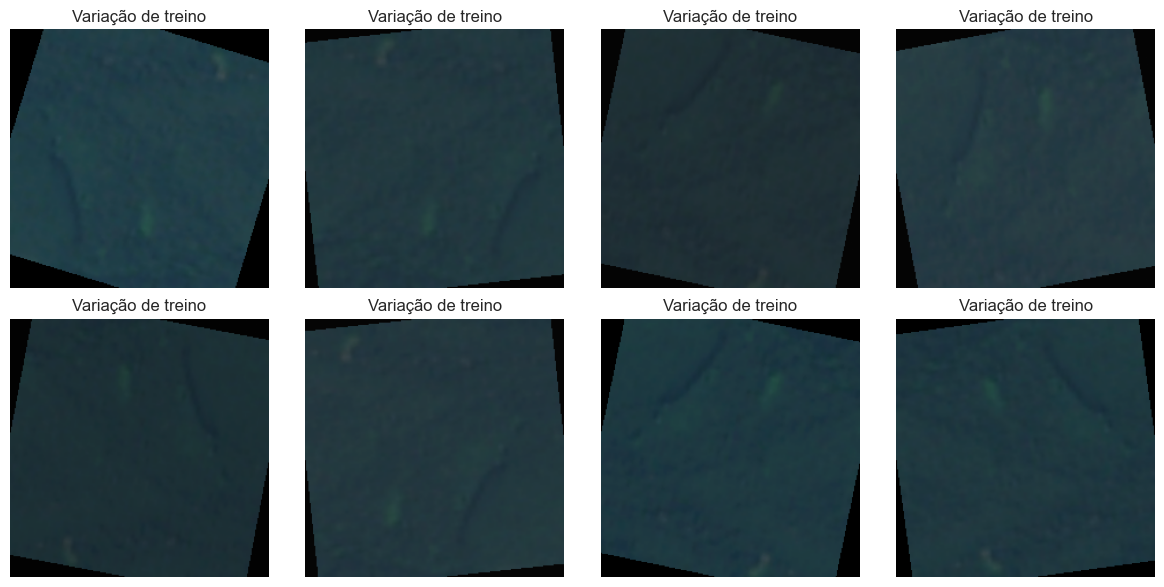

In [25]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Construir transformações distintas para treino e para avaliação.
# -----------------------------------------------------------------------------
# A pipeline de treino cria variações plausíveis para reduzir sobreajuste.
transform_treino = transforms.Compose([
    transforms.RandomResizedCrop(
        CFG.img_size,
        scale=(0.85, 1.0),
        interpolation=InterpolationMode.BILINEAR,
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20, interpolation=InterpolationMode.BILINEAR),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN_IMAGENET, STD_IMAGENET),
])
# Validação e teste são determinísticos para manter a régua de avaliação fixa.
transform_avaliacao = transforms.Compose([
    transforms.Resize((CFG.img_size, CFG.img_size), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(MEAN_IMAGENET, STD_IMAGENET),
])

# Repetir a mesma transformação evidencia sua natureza aleatória.
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax in axes.flat:
    x_aug = transform_treino(imagem_pil)
    ax.imshow(desnormalizar(x_aug, MEAN_IMAGENET, STD_IMAGENET).permute(1, 2, 0))
    ax.set_title("Variação de treino")
    ax.axis("off")
plt.tight_layout()


### Checkpoint 4 — resposta

ReLU remove ativações negativas; MaxPool reduz custo e resolução espacial. Augmentation aumenta diversidade, não cria informação nova. Treino recebe variações moderadas; validação/teste usam transformação determinística para medir sempre o mesmo problema. Transformações agressivas podem apagar sinais úteis.

**Conclusão da seção:** a pipeline de treino ensina invariâncias plausíveis; a de avaliação mantém a régua estável.


## 11. Análise exploratória e qualidade dos dados

**Pergunta de aprendizagem:** há desbalanceamento, arquivos ilegíveis, formatos inesperados ou duplicatas exatas?


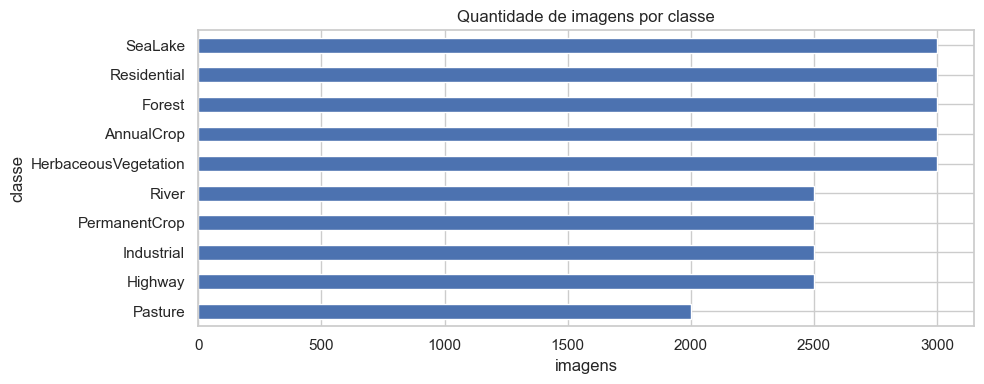

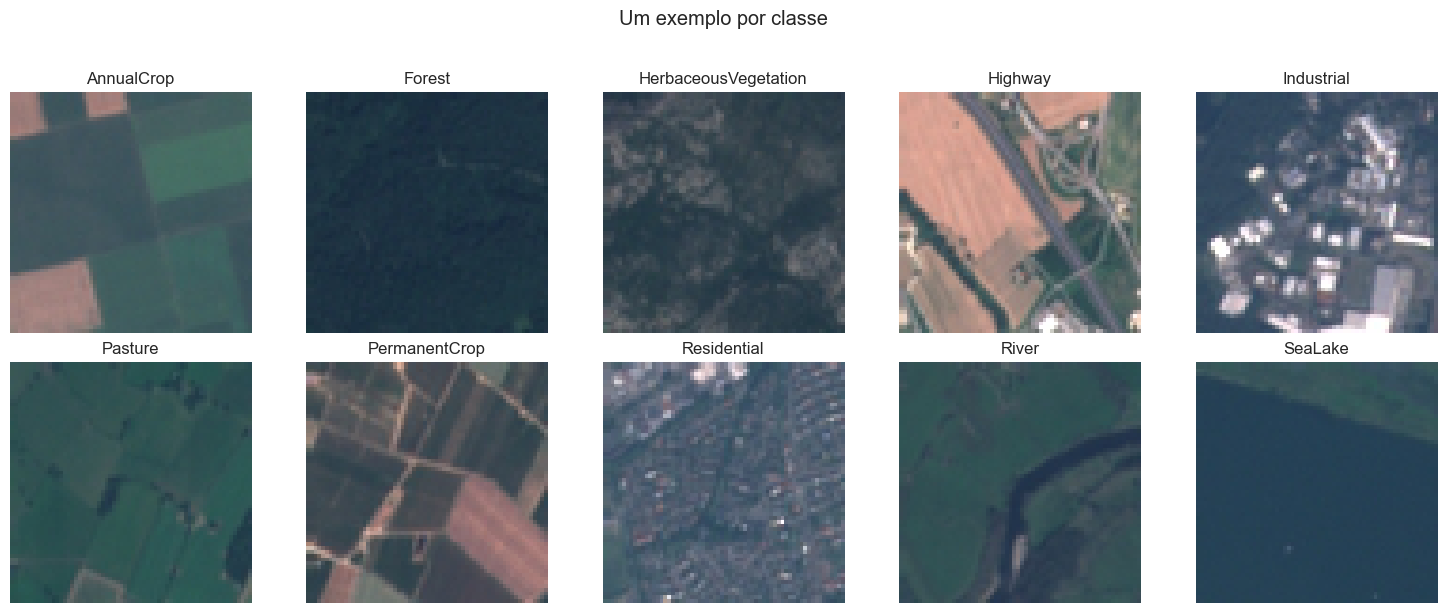

In [26]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Examinar distribuição e exemplos representativos das dez classes.
# -----------------------------------------------------------------------------
# O gráfico de barras permite detectar rapidamente desbalanceamento entre classes.
fig, ax = plt.subplots(figsize=(10, 4))
inventario["imagens"].sort_values().plot.barh(ax=ax)
ax.set_title("Quantidade de imagens por classe")
ax.set_xlabel("imagens")
ax.set_ylabel("classe")
plt.tight_layout()

# Em seguida, amostramos uma imagem reproduzível de cada uma das dez classes.
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, classe in zip(axes.flat, CLASSES):
    linha = df_arquivos[df_arquivos["classe"].eq(classe)].sample(1, random_state=SEED).iloc[0]
    with Image.open(linha["caminho"]) as img:
        ax.imshow(img.convert("RGB"))
    ax.set_title(classe)
    ax.axis("off")
fig.suptitle("Um exemplo por classe", y=1.02)
plt.tight_layout()


In [27]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Verificar resolução, modo de cor e legibilidade dos arquivos.
# -----------------------------------------------------------------------------
# A função isola o tratamento de erro para que um arquivo ruim não esconda os demais.
def inspecionar_arquivo(caminho: Path) -> dict:
    """Valida a imagem e retorna suas propriedades básicas."""
    try:
        # verify valida a integridade sem decodificar toda a imagem.
        with Image.open(caminho) as img:
            img.verify()
        # Reabrimos porque verify encerra o uso normal do objeto PIL.
        with Image.open(caminho) as img:
            return {"largura": img.width, "altura": img.height, "modo": img.mode, "erro": None}
    except Exception as exc:
        return {"largura": np.nan, "altura": np.nan, "modo": None, "erro": repr(exc)}


# No modo rápido inspecionamos uma amostra; na execução completa, todos os arquivos.
if MODO_RAPIDO:
    tamanho_amostra = min(1500, len(df_arquivos))
    amostra_qc = df_arquivos.sample(tamanho_amostra, random_state=SEED)
else:
    amostra_qc = df_arquivos

# Convertemos os diagnósticos em tabela para resumir formatos e erros.
qc = pd.DataFrame([inspecionar_arquivo(p) for p in amostra_qc["caminho"]])
resumo_qualidade = (
    qc.groupby(["largura", "altura", "modo"], dropna=False)
    .size()
    .rename("arquivos")
    .reset_index()
)
display(resumo_qualidade)
print("Arquivos ilegíveis na verificação:", qc["erro"].notna().sum())


,largura,altura,modo,arquivos
0,64,64,RGB,1500


Arquivos ilegíveis na verificação: 0


In [28]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Detectar conteúdo duplicado antes da criação dos splits.
# -----------------------------------------------------------------------------
# MD5 é usado somente como impressão digital rápida de conteúdo, não para segurança.
def md5_arquivo(caminho: Path, bloco: int = 1 << 20) -> str:
    """Calcula uma impressão digital para detectar cópias exatas."""
    h = hashlib.md5()  # usado como impressão digital, não para segurança
    # Leitura em blocos evita carregar cada arquivo inteiro na memória.
    with caminho.open("rb") as f:
        while pedaco := f.read(bloco):
            h.update(pedaco)
    return h.hexdigest()


# Hashes iguais indicam cópias byte a byte do mesmo arquivo.
df_arquivos["md5"] = df_arquivos["caminho"].map(md5_arquivo)
duplicatas_exatas = df_arquivos.loc[df_arquivos["md5"].duplicated(keep=False)].sort_values("md5")
# A mesma imagem com rótulos diferentes representa inconsistência grave.
conflitos = duplicatas_exatas.groupby("md5")["classe"].nunique().gt(1)
if conflitos.any():
    raise ValueError(
        "Há imagens idênticas com rótulos diferentes. "
        "Revise esses arquivos antes de modelar."
    )
print(f"Cópias duplicadas encontradas: {len(duplicatas_exatas)}")
display(duplicatas_exatas[["caminho_relativo", "classe", "md5"]].head(20))


Cópias duplicadas encontradas: 0


,caminho_relativo,classe,md5


**Interpretação:** `AnnualCrop`, `PermanentCrop`, `Pasture` e `HerbaceousVegetation` podem compartilhar texturas; `Highway` e `River` podem compartilhar estruturas lineares. Duplicatas exatas atravessando splits seriam vazamento e devem ser agrupadas ou removidas antes de continuar.

**Conclusão da seção:** qualidade não é só “o arquivo abre”; inclui distribuição, resolução, ambiguidade visual e independência entre amostras.


## 12. Separação estratificada, Dataset e DataLoaders

**Pergunta de aprendizagem:** como garantir exatamente os mesmos splits em todos os experimentos?

Criamos o split uma vez, persistimos caminhos relativos e registramos um fingerprint. Augmentation não participa da divisão.


In [29]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Criar ou carregar splits estratificados, persistentes e sem vazamento.
# -----------------------------------------------------------------------------
# Reutilizar o CSV existente garante os mesmos exemplos em todos os modelos.
if SPLIT_FILE.exists():
    df_splits = pd.read_csv(SPLIT_FILE)
    esperadas = {"caminho_relativo", "classe", "label", "split"}
    if not esperadas.issubset(df_splits.columns):
        raise ValueError(f"Split existente inválido: faltam {esperadas - set(df_splits.columns)}")
else:
    # Se ainda não existe CSV, criamos uma única divisão oficial.
    # Uma única cópia por conteúdo impede que arquivos idênticos atravessem splits.
    df_para_split = df_arquivos.drop_duplicates("md5", keep="first").copy()
    # Primeiro isolamos o teste, que permanecerá intocado durante a seleção.
    treino_val, teste = train_test_split(
        df_para_split, test_size=CFG.test_size, random_state=SEED, stratify=df_para_split["classe"]
    )
    # Ajustamos a fração relativa porque a segunda divisão ocorre sem o teste.
    fracao_val_relativa = CFG.val_size / (1 - CFG.test_size)
    treino, validacao = train_test_split(
        treino_val, test_size=fracao_val_relativa, random_state=SEED, stratify=treino_val["classe"]
    )
    # Registramos o nome do split em cada linha antes de concatenar.
    partes = []
    for nome, parte in (("treino", treino), ("validacao", validacao), ("teste", teste)):
        partes.append(parte.assign(split=nome))
    colunas_split = ["caminho_relativo", "classe", "label", "split"]
    df_splits = pd.concat(partes, ignore_index=True)[colunas_split]
    df_splits.to_csv(SPLIT_FILE, index=False)

# Caminhos relativos tornam o CSV portátil; caminhos absolutos são reconstruídos em memória.
df_splits["caminho"] = df_splits["caminho_relativo"].map(lambda p: ROOT / p)
arquivos_existem = df_splits["caminho"].map(Path.exists).all()
assert arquivos_existem, "O arquivo de split aponta para imagens ausentes."
# Reanexamos os hashes para confirmar que nenhuma duplicata atravessa os splits.
hash_por_caminho = df_arquivos.set_index("caminho_relativo")["md5"]
df_splits["md5"] = df_splits["caminho_relativo"].map(hash_por_caminho)
if df_splits["md5"].isna().any() or df_splits["md5"].duplicated().any():
    raise ValueError(
        "O split persistido contém caminhos desconhecidos ou conteúdo duplicado; "
        "revise-o e regenere."
    )
assert_splits_disjuntos(df_splits)
print("Fingerprint do split:", fingerprint_splits(df_splits))
display(pd.crosstab(df_splits["classe"], df_splits["split"], margins=True))


Fingerprint do split: c3b4fc18906f34dc


split,teste,treino,validacao,All
classe,,,,
AnnualCrop,450,2100,450,3000
Forest,450,2100,450,3000
HerbaceousVegetation,450,2099,451,3000
Highway,375,1750,375,2500
Industrial,375,1750,375,2500
Pasture,300,1400,300,2000
PermanentCrop,375,1750,375,2500
Residential,450,2100,450,3000
River,375,1750,375,2500


In [30]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Implementar o Dataset e criar DataLoaders reprodutíveis.
# -----------------------------------------------------------------------------
# O Dataset guarda apenas caminhos e abre cada imagem sob demanda.
class EuroSATPaths(Dataset):
    '''Dataset orientado pela tabela persistida de caminhos e splits.'''

    def __init__(
        self,
        tabela: pd.DataFrame,
        transformacao: Callable,
    ) -> None:
        # Resetar o índice permite acessar qualquer amostra por posição inteira.
        self.tabela = tabela.reset_index(drop=True).copy()
        self.transformacao = transformacao

    # O DataLoader consulta este método para saber quantas amostras existem.
    def __len__(self) -> int:
        return len(self.tabela)

    # Retorna exatamente um par (imagem transformada, rótulo inteiro).
    def __getitem__(self, indice: int) -> tuple[torch.Tensor, int]:
        linha = self.tabela.iloc[indice]

        # A imagem é aberta somente quando solicitada, evitando manter
        # milhares de arquivos simultaneamente na memória.
        with Image.open(linha["caminho"]) as img:
            imagem = img.convert("RGB")

        # A transformação adequada ao split é aplicada somente neste momento.
        return self.transformacao(imagem), int(linha["label"])


# Esta função centraliza a ordem treino, validação e teste.
def tabelas_experimento(
    modo_rapido: bool = MODO_RAPIDO,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Retorna treino, validação e teste na ordem oficial."""
    nomes_splits = ("treino", "validacao", "teste")
    partes = [
        df_splits[df_splits["split"].eq(nome)].copy()
        for nome in nomes_splits
    ]

    # A redução é feita dentro de cada split e mantém todas as classes.
    if modo_rapido:
        partes = [subconjunto_rapido(parte) for parte in partes]

    return tuple(partes)


# Constrói os três DataLoaders a partir da mesma tabela oficial.
def criar_loaders(
    batch_size: int,
    modo_rapido: bool = MODO_RAPIDO,
    transform_train: Callable = transform_treino,
    transform_eval: Callable = transform_avaliacao,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Cria os três DataLoaders com transformações apropriadas."""
    treino_df, val_df, teste_df = tabelas_experimento(modo_rapido)
    # Somente o treino recebe augmentation; validação e teste são determinísticos.
    datasets = (
        EuroSATPaths(treino_df, transform_train),
        EuroSATPaths(val_df, transform_eval),
        EuroSATPaths(teste_df, transform_eval),
    )
    # shuffle ocorre apenas no treino; pin_memory acelera transferências para CUDA.
    loaders = tuple(
        DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=(indice == 0),
            num_workers=CFG.num_workers,
            pin_memory=torch.cuda.is_available(),
            worker_init_fn=worker_seed,
            generator=criar_gerador(SEED),
            persistent_workers=CFG.num_workers > 0,
        )
        for indice, dataset in enumerate(datasets)
    )
    return loaders


# Um primeiro lote confirma imediatamente shapes e integração do pipeline.
train_loader, val_loader, test_loader = criar_loaders(batch_size=32)
x_batch, y_batch = next(iter(train_loader))
print("Batch NCHW:", tuple(x_batch.shape), "| labels N:", tuple(y_batch.shape))


Batch NCHW: (32, 3, 224, 224) | labels N: (32,)


### Checkpoint 5 — resposta

Todos os modelos leem `splits_eurosat_seed42.csv`; somente a transformação e o `batch_size` podem mudar. O teste não seleciona arquitetura, hiperparâmetros, época ou modelo. O fingerprint permite detectar alterações acidentais.

## O que aprendemos antes de modelar

O arquivo comprimido foi decodificado em pixels RGB, convertido de `uint8 HWC` para `float32 CHW`, redimensionado, normalizado e agrupado em lotes NCHW. Vimos filtros fixos, feature maps, ReLU, pooling e augmentation. Agora os modelos podem receber a mesma evidência, sem vazamento.


# Parte II — Modelagem e benchmark

## 13. Baseline e protocolo experimental comum

**Pergunta de aprendizagem:** como acompanhar o início, o meio e o fim de cada experimento sem esconder etapas importantes?

Nesta Parte II, a repetição é **intencional e pedagógica**. Cada modelo apresenta novamente seu próprio fluxo:

1. Separar treino, validação e teste.
2. Criar transformações quando forem específicas do modelo.
3. Criar Dataset.
4. Criar DataLoader.
5. Construir ou carregar o modelo.
6. Definir loss.
7. Definir otimizador e scheduler.
8. Executar treino.
9. Executar validação.
10. Selecionar a melhor época ou configuração.
11. Avaliar uma única vez no teste.
12. Calcular métricas, criar gráficos e salvar artefatos.

Algumas linhas poderiam ser transformadas em funções reutilizáveis, mas foram mantidas visíveis para permitir acompanhar todo o processo de cada técnica de forma independente.

### O que continua igual para garantir uma comparação justa

- split e semente idênticos;
- seleção por **F1 Macro de validação**;
- teste intocado até a versão final;
- métricas comuns: accuracy, precision/recall/F1 Macro, Log Loss, AUC OVR Macro e F1 por classe;
- custos comuns: treino, inferência, parâmetros treináveis e tamanho do artefato.

Uma baseline majoritária contextualiza o problema, mas não integra as quatro metodologias finais.

In [31]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Iniciar a Parte II e registrar claramente o protocolo comum.
# -----------------------------------------------------------------------------
# A Parte II evita funções genéricas de treino e avaliação.
# Cada modelo terá seu próprio fluxo explícito:
# dados -> DataLoaders -> modelo -> loss -> otimizador -> treino -> validação -> teste.
RESULTADOS = {}

# Esta tabela funciona como um contrato do benchmark.
# As regras abaixo serão repetidas e aplicadas em cada modelo.
protocolo_benchmark = pd.DataFrame({
    "regra": [
        "Split",
        "Seleção do melhor modelo",
        "Uso do teste",
        "Métrica principal",
        "Métricas complementares",
        "Custos registrados",
    ],
    "decisão": [
        "Mesmo CSV splits_eurosat_seed42.csv",
        "F1 Macro de validação",
        "Uma única vez após finalizar as decisões",
        "F1 Macro",
        "Accuracy, Precision Macro, Recall Macro, Log Loss, AUC e F1 por classe",
        "Tempo de treino, inferência, parâmetros treináveis e tamanho",
    ],
})

display(protocolo_benchmark)
print("Dispositivo dos experimentos:", DEVICE)
print("Modo rápido:", MODO_RAPIDO)
print("Treinamentos autorizados:", EXECUTAR_TREINOS)

In [32]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Calcular uma baseline simples antes dos modelos neurais.
# -----------------------------------------------------------------------------
# Separamos explicitamente a validação usando o CSV oficial.
baseline_validacao_df = df_splits[
    df_splits["split"].eq("validacao")
].copy()

# No modo rápido, usamos até 120 exemplos de cada classe.
if MODO_RAPIDO:
    partes_baseline = []

    for _, grupo_classe in baseline_validacao_df.groupby("classe"):
        quantidade = min(120, len(grupo_classe))

        partes_baseline.append(
            grupo_classe.sample(
                n=quantidade,
                random_state=SEED,
            )
        )

    baseline_validacao_df = pd.concat(
        partes_baseline,
        ignore_index=True,
    )

# A classe majoritária é descoberta somente no treino.
classe_majoritaria = (
    df_splits.loc[
        df_splits["split"].eq("treino"),
        "label",
    ]
    .mode()
    .iloc[0]
)

# A baseline prevê a mesma classe para todas as imagens de validação.
y_baseline = baseline_validacao_df["label"].to_numpy()
pred_baseline = np.full(
    shape=len(y_baseline),
    fill_value=classe_majoritaria,
)

# Calculamos as métricas diretamente, sem esconder a operação em uma função.
metricas_baseline = pd.DataFrame({
    "métrica": [
        "Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1 Macro",
    ],
    "valor": [
        accuracy_score(y_baseline, pred_baseline),
        precision_score(y_baseline, pred_baseline, average="macro", zero_division=0),
        recall_score(y_baseline, pred_baseline, average="macro", zero_division=0),
        f1_score(y_baseline, pred_baseline, average="macro", zero_division=0),
    ],
})

print("Classe prevista pela baseline:", CLASSES[int(classe_majoritaria)])
display(metricas_baseline)

Baseline majoritária — F1 Macro (validação): 0.01818181818181818


**Interpretação:** accuracy pode parecer aceitável mesmo ignorando classes; F1 Macro pune esse comportamento. AUC usa probabilidades e mede separação OVR, mas não substitui análise da matriz de confusão.

**Conclusão da seção:** o protocolo separa seleção (validação) de estimativa final (teste) e mede desempenho e custo.


## 14. CNN desenvolvida do zero

**Pergunta de aprendizagem:** o que uma CNN consegue aprender sem pesos externos?

### Ideia central: uma única rede processa o batch inteiro

Não existem 32 CNNs diferentes quando `batch_size=32`. Existe **uma única CNN**, com um único conjunto de pesos compartilhados, aplicada paralelamente às 32 imagens. A dimensão `N` identifica as imagens e nunca é misturada pelo `Flatten`.

```text
32 imagens RGB transformadas
(N, C, H, W) = (32, 3, 224, 224)
        ↓
Bloco 1: Conv → BatchNorm → ReLU → MaxPool → Dropout2d
(32, 32, 112, 112)
        ↓
Bloco 2: Conv → BatchNorm → ReLU → MaxPool → Dropout2d
(32, 64, 56, 56)
        ↓
Bloco 3: Conv → BatchNorm → ReLU → MaxPool → Dropout2d
(32, 128, 28, 28)
        ↓
AdaptiveAvgPool2d(4, 4)
(32, 128, 4, 4)
        ↓
Flatten por imagem
(32, 2048)
        ↓
Linear → ReLU → Dropout
(32, 256)
        ↓
Linear de saída
(32, 10 logits)
```

Os valores acima usam a configuração padrão `filtros=32` e `dimensao_fc=256`. O primeiro eixo continua representando as 32 imagens durante todo o percurso.

### 1. Convolução: procurar padrões locais

Um filtro não observa a imagem inteira de uma vez. Para produzir uma ativação, ele combina uma pequena janela dos canais de entrada com seus pesos:

$$
Y_{n,k,i,j} = b_k + \sum_c \sum_u \sum_v W_{k,c,u,v}\,X_{n,c,i+u,j+v}
$$

- $n$: imagem dentro do batch;
- $k$: filtro e canal de saída;
- $c$: canal de entrada;
- $(i,j)$: posição espacial;
- $(u,v)$: posição dentro do kernel;
- $W$: pesos aprendidos por backpropagation.

Com kernel $3\times3$, `stride=1` e `padding=1`, a convolução preserva altura e largura. A dimensão de saída por eixo é:

$$
H_{out}=\left\lfloor\frac{H+2P-K}{S}\right\rfloor+1
$$

### 2. Batch Normalization: estabilizar as ativações

Para cada canal, a BatchNorm normaliza as ativações do mini-batch e aprende uma nova escala e deslocamento:

$$
\hat{x}=\frac{x-\mu_B}{\sqrt{\sigma_B^2+\varepsilon}},\qquad y=\gamma\hat{x}+\beta
$$

Durante o treino, $\mu_B$ e $\sigma_B^2$ vêm do batch. Durante a avaliação, `modelo.eval()` utiliza as estatísticas acumuladas.

### 3. ReLU: introduzir não linearidade

$$
ReLU(x)=\max(0,x)
$$

Sem uma ativação não linear, várias convoluções seriam equivalentes a uma única transformação linear e a rede teria menor capacidade de representar padrões complexos.

### 4. Max Pooling: reduzir a resolução espacial

O `MaxPool2d(2)` divide cada feature map em regiões $2\times2$ e conserva o maior valor. Assim, `224 → 112 → 56 → 28`. O número de canais não muda no pooling; apenas `H` e `W` diminuem.

### 5. Dropout: regularizar

Durante o treino, o Dropout zera aleatoriamente parte das ativações. Isso reduz dependências excessivas entre features. Na avaliação, `modelo.eval()` desativa esse sorteio e utiliza toda a rede.

### 6. Pool adaptativo e Flatten

O `AdaptiveAvgPool2d((4,4))` resume cada um dos 128 canais em uma grade $4\times4$. Depois, o Flatten reorganiza **cada imagem separadamente**:

$$
128\times4\times4=2048	ext{ características por imagem}
$$

Portanto, `(32,128,4,4)` vira `(32,2048)`, e não um único vetor misturando o batch.

### 7. Camadas densas, logits e probabilidades

A última camada produz dez logits $z_1,\ldots,z_{10}$ por imagem. Logits são escores livres, ainda não probabilidades. A Softmax os converte em probabilidades que somam 1:

$$
p_k=\frac{e^{z_k}}{\sum_{j=1}^{10}e^{z_j}}
$$

No treino, `CrossEntropyLoss` combina internamente LogSoftmax e Log Loss. Para um batch com $N$ imagens:

$$
\mathcal{L}=-\frac{1}{N}\sum_{n=1}^{N}\log p_{n,y_n}
$$

### 8. Uma atualização dos pesos por batch

```text
32 imagens → forward → 32 previsões → loss média
→ backward → gradientes médios → optimizer.step()
→ uma atualização dos pesos compartilhados
```

| Teoria | Implementação abaixo |
|---|---|
| Extração de padrões locais | `nn.Conv2d` |
| Normalização das ativações | `nn.BatchNorm2d` |
| Não linearidade | `nn.ReLU` |
| Redução espacial | `nn.MaxPool2d` e `nn.AdaptiveAvgPool2d` |
| Regularização | `nn.Dropout2d` e `nn.Dropout` |
| Vetor por imagem | `nn.Flatten` |
| Dez escores de classe | `nn.Linear(..., num_classes)` |


In [ ]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Construir a CNN em blocos explícitos e acompanhar o forward.
# -----------------------------------------------------------------------------
class CNNDoZero(nn.Module):
    """CNN didática construída manualmente para as dez classes do EuroSAT."""

    def __init__(
        self,
        num_classes: int = 10,
        filtros: int = 32,
        dimensao_fc: int = 256,
        dropout: float = 0.35,
    ):
        super().__init__()

        # BLOCO 1: (N, 3, 224, 224) -> (N, filtros, 112, 112)
        self.bloco1 = nn.Sequential(
            nn.Conv2d(3, filtros, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(filtros),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(dropout / 2),
        )

        # BLOCO 2: (N, filtros, 112, 112) -> (N, filtros*2, 56, 56)
        self.bloco2 = nn.Sequential(
            nn.Conv2d(filtros, filtros * 2, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(filtros * 2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(dropout / 2),
        )

        # BLOCO 3: (N, filtros*2, 56, 56) -> (N, filtros*4, 28, 28)
        self.bloco3 = nn.Sequential(
            nn.Conv2d(filtros * 2, filtros * 4, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(filtros * 4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(dropout / 2),
        )

        # Resume cada feature map em uma grade fixa 4 x 4.
        self.pool_adaptativo = nn.AdaptiveAvgPool2d((4, 4))

        # Converte as features em dez logits.
        self.classificador = nn.Sequential(
            nn.Flatten(),
            nn.Linear(filtros * 4 * 4 * 4, dimensao_fc),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(dimensao_fc, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Executa cronologicamente os três blocos e o classificador."""
        x = self.bloco1(x)
        x = self.bloco2(x)
        x = self.bloco3(x)
        x = self.pool_adaptativo(x)
        logits = self.classificador(x)
        return logits


# Criamos uma CNN apenas para conferir arquitetura e shapes.
cnn_demo = CNNDoZero(
    num_classes=len(CLASSES),
    filtros=32,
    dimensao_fc=256,
    dropout=0.35,
).to(DEVICE)

print(cnn_demo)

# Um forward sem gradientes confirma entrada e saída.
with torch.no_grad():
    batch_demo = x_batch.to(DEVICE)
    logits_demo = cnn_demo(batch_demo)

print("Entrada:", tuple(batch_demo.shape))
print("Saída:", tuple(logits_demo.shape))
print("Uma linha de 10 logits para cada imagem do batch.")

**Interpretação:** cada bloco aumenta canais (mais tipos de padrão) e reduz altura/largura (menor custo espacial). `AdaptiveAvgPool2d` impede que a camada densa dependa de uma conta manual frágil.

**Conclusão da seção:** esta arquitetura aprende todos os filtros apenas com o EuroSAT e será otimizada, sem comparar ativações, poolings ou otimizadores.


## 15. Otimização da CNN com Optuna

**Pergunta de aprendizagem:** como escolher poucos hiperparâmetros sem tocar no teste?

### Parâmetros aprendidos versus hiperparâmetros

Os pesos dos filtros são **parâmetros aprendidos** pelo backpropagation. Já learning rate, quantidade de filtros e dropout são **hiperparâmetros** definidos antes do treinamento. O Optuna automatiza a escolha de uma combinação pequena e controlada desses hiperparâmetros.

A pergunta matemática da busca é:

$$
\theta^*=\arg\max_{\theta}F1_{macro}^{validação}(\theta)
$$

Aqui, $\theta$ representa uma configuração da CNN. O objetivo usa somente o F1 Macro da **validação**, nunca o teste.

### Fluxo cronológico de uma tentativa

```text
Optuna sugere uma configuração θ
        ↓
Cria novos DataLoaders com o batch_size sugerido
        ↓
Cria uma nova CNN com filtros, dimensão FC e dropout sugeridos
        ↓
Treina com Adam usando learning_rate e weight_decay sugeridos
        ↓
Early stopping seleciona a melhor época pela validação
        ↓
Devolve o maior F1 Macro de validação ao Optuna
        ↓
Descarta o checkpoint temporário e inicia a próxima tentativa
```

O sampler TPE utiliza resultados anteriores para privilegiar regiões promissoras do espaço de busca. Isso é mais eficiente que testar cegamente todas as combinações, mas não garante encontrar um ótimo global.

| Hiperparâmetro | Efeito prático |
|---|---|
| `learning_rate` | Tamanho de cada atualização dos pesos |
| `batch_size` | Imagens por atualização e consumo de memória |
| `filtros` | Quantidade de padrões que cada bloco pode representar |
| `dimensao_fc` | Capacidade da camada densa |
| `dropout` | Intensidade da regularização |
| `weight_decay` | Penalização de pesos grandes |

ReLU, MaxPool, BatchNorm, Adam, CrossEntropyLoss e ReduceLROnPlateau permanecem fixos. Assim, a busca responde uma pergunta limitada e interpretável, em vez de alterar toda a metodologia ao mesmo tempo.

### Depois da busca

A melhor configuração é treinada novamente. A melhor época é escolhida na validação e, somente então, o checkpoint definitivo é avaliado uma vez no teste. Esse isolamento evita adaptar decisões ao resultado final.


In [ ]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Executar a busca Optuna mostrando o ciclo completo de cada tentativa.
# -----------------------------------------------------------------------------
# O Optuna exige uma função objetivo. Esta é a única função de treino abstrata
# desta seção porque a biblioteca precisa chamá-la repetidamente.
def objetivo_cnn(trial):
    """Treina uma configuração da CNN e devolve o melhor F1 Macro de validação."""

    # -------------------------------------------------------------------------
    # 1. HIPERPARÂMETROS SUGERIDOS NESTA TENTATIVA
    # -------------------------------------------------------------------------
    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        3e-3,
        log=True,
    )
    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64],
    )
    filtros = trial.suggest_categorical(
        "filtros",
        [24, 32, 48],
    )
    dimensao_fc = trial.suggest_categorical(
        "dimensao_fc",
        [128, 256, 384],
    )
    dropout = trial.suggest_float(
        "dropout",
        0.20,
        0.50,
    )
    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-3,
        log=True,
    )

    # -------------------------------------------------------------------------
    # 2. TABELAS DE TREINO E VALIDAÇÃO
    # O teste não aparece em nenhum ponto da busca.
    # -------------------------------------------------------------------------
    cnn_treino_trial_df = df_splits[
        df_splits["split"].eq("treino")
    ].copy()

    cnn_validacao_trial_df = df_splits[
        df_splits["split"].eq("validacao")
    ].copy()

    if MODO_RAPIDO:
        cnn_treino_trial_df = subconjunto_rapido(
            cnn_treino_trial_df,
            n_por_classe=120,
        )
        cnn_validacao_trial_df = subconjunto_rapido(
            cnn_validacao_trial_df,
            n_por_classe=120,
        )

    # -------------------------------------------------------------------------
    # 3. DATASETS E DATALOADERS DESTA TENTATIVA
    # -------------------------------------------------------------------------
    dataset_treino_trial = EuroSATPaths(
        cnn_treino_trial_df,
        transform_treino,
    )
    dataset_validacao_trial = EuroSATPaths(
        cnn_validacao_trial_df,
        transform_avaliacao,
    )

    loader_treino_trial = DataLoader(
        dataset_treino_trial,
        batch_size=batch_size,
        shuffle=True,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_seed,
        generator=criar_gerador(SEED),
    )

    loader_validacao_trial = DataLoader(
        dataset_validacao_trial,
        batch_size=batch_size,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_seed,
    )

    # -------------------------------------------------------------------------
    # 4. MODELO, LOSS, OTIMIZADOR E SCHEDULER
    # -------------------------------------------------------------------------
    modelo_trial = CNNDoZero(
        num_classes=len(CLASSES),
        filtros=filtros,
        dimensao_fc=dimensao_fc,
        dropout=dropout,
    ).to(DEVICE)

    loss_fn_trial = nn.CrossEntropyLoss()

    optimizer_trial = torch.optim.Adam(
        modelo_trial.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    scheduler_trial = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_trial,
        mode="min",
        patience=2,
        factor=0.5,
    )

    melhor_f1_trial = -np.inf
    epocas_sem_melhora = 0
    max_epocas_trial = 8 if MODO_RAPIDO else 20

    # -------------------------------------------------------------------------
    # 5. TREINO E VALIDAÇÃO DA TENTATIVA
    # -------------------------------------------------------------------------
    for epoca in range(1, max_epocas_trial + 1):

        # ----------------------------- TREINO --------------------------------
        modelo_trial.train()
        soma_loss_treino = 0.0

        for imagens, labels in loader_treino_trial:
            imagens = imagens.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer_trial.zero_grad(set_to_none=True)

            logits = modelo_trial(imagens)
            loss = loss_fn_trial(logits, labels)

            loss.backward()
            nn.utils.clip_grad_norm_(
                modelo_trial.parameters(),
                max_norm=1.0,
            )
            optimizer_trial.step()

            soma_loss_treino += loss.item()

        loss_treino_media = (
            soma_loss_treino / len(loader_treino_trial)
        )

        # --------------------------- VALIDAÇÃO -------------------------------
        modelo_trial.eval()
        soma_loss_validacao = 0.0
        labels_validacao = []
        predicoes_validacao = []

        with torch.no_grad():
            for imagens, labels in loader_validacao_trial:
                imagens = imagens.to(DEVICE, non_blocking=True)
                labels_device = labels.to(DEVICE, non_blocking=True)

                logits = modelo_trial(imagens)
                loss = loss_fn_trial(logits, labels_device)

                predicoes = logits.argmax(dim=1)

                soma_loss_validacao += loss.item()
                labels_validacao.append(labels.numpy())
                predicoes_validacao.append(
                    predicoes.cpu().numpy()
                )

        loss_validacao_media = (
            soma_loss_validacao / len(loader_validacao_trial)
        )

        y_validacao = np.concatenate(labels_validacao)
        pred_validacao = np.concatenate(predicoes_validacao)

        f1_validacao = f1_score(
            y_validacao,
            pred_validacao,
            average="macro",
            zero_division=0,
        )

        scheduler_trial.step(loss_validacao_media)

        print(
            f"Trial {trial.number:02d} | "
            f"Época {epoca:02d} | "
            f"Loss treino {loss_treino_media:.4f} | "
            f"Loss validação {loss_validacao_media:.4f} | "
            f"F1 validação {f1_validacao:.4f}"
        )

        # Early stopping baseado exclusivamente na validação.
        if f1_validacao > melhor_f1_trial + 1e-4:
            melhor_f1_trial = f1_validacao
            epocas_sem_melhora = 0
        else:
            epocas_sem_melhora += 1

            if epocas_sem_melhora >= 3:
                break

    # Libera referências da tentativa antes de iniciar a próxima.
    del modelo_trial
    limpar_memoria()

    return float(melhor_f1_trial)


# -----------------------------------------------------------------------------
# 6. CRIAÇÃO E EXECUÇÃO DO ESTUDO
# -----------------------------------------------------------------------------
if EXECUTAR_TREINOS:
    exigir_pacote("optuna")
    import optuna

    estudo_cnn = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )

    estudo_cnn.optimize(
        objetivo_cnn,
        n_trials=5 if MODO_RAPIDO else CFG.n_trials,
    )

    print("Melhor F1 de validação:", estudo_cnn.best_value)
    print("Melhores hiperparâmetros:")
    display(pd.Series(estudo_cnn.best_params))
else:
    print(
        "Busca Optuna desativada. "
        "Defina EXECUTAR_TREINOS=True quando quiser executá-la."
    )

In [ ]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Treinar a CNN final do início ao fim e avaliar no teste.
# -----------------------------------------------------------------------------
if EXECUTAR_TREINOS:
    from sklearn.metrics import log_loss

    # -------------------------------------------------------------------------
    # 1. RECUPERAR A MELHOR CONFIGURAÇÃO ENCONTRADA PELO OPTUNA
    # -------------------------------------------------------------------------
    melhores_cnn = estudo_cnn.best_params

    print("Configuração final da CNN:")
    display(pd.Series(melhores_cnn))

    # -------------------------------------------------------------------------
    # 2. SEPARAR EXPLICITAMENTE TREINO, VALIDAÇÃO E TESTE
    # -------------------------------------------------------------------------
    cnn_treino_df = df_splits[
        df_splits["split"].eq("treino")
    ].copy()

    cnn_validacao_df = df_splits[
        df_splits["split"].eq("validacao")
    ].copy()

    cnn_teste_df = df_splits[
        df_splits["split"].eq("teste")
    ].copy()

    if MODO_RAPIDO:
        cnn_treino_df = subconjunto_rapido(cnn_treino_df, 120)
        cnn_validacao_df = subconjunto_rapido(cnn_validacao_df, 120)
        cnn_teste_df = subconjunto_rapido(cnn_teste_df, 120)

    print(
        "Imagens | treino:",
        len(cnn_treino_df),
        "| validação:",
        len(cnn_validacao_df),
        "| teste:",
        len(cnn_teste_df),
    )

    # -------------------------------------------------------------------------
    # 3. CRIAR DATASETS
    # Treino recebe augmentation; validação e teste não recebem.
    # -------------------------------------------------------------------------
    dataset_cnn_treino = EuroSATPaths(
        cnn_treino_df,
        transform_treino,
    )
    dataset_cnn_validacao = EuroSATPaths(
        cnn_validacao_df,
        transform_avaliacao,
    )
    dataset_cnn_teste = EuroSATPaths(
        cnn_teste_df,
        transform_avaliacao,
    )

    # -------------------------------------------------------------------------
    # 4. CRIAR DATALOADERS
    # -------------------------------------------------------------------------
    batch_size_cnn = melhores_cnn["batch_size"]

    loader_cnn_treino = DataLoader(
        dataset_cnn_treino,
        batch_size=batch_size_cnn,
        shuffle=True,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_seed,
        generator=criar_gerador(SEED),
    )

    loader_cnn_validacao = DataLoader(
        dataset_cnn_validacao,
        batch_size=batch_size_cnn,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_seed,
    )

    loader_cnn_teste = DataLoader(
        dataset_cnn_teste,
        batch_size=batch_size_cnn,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_seed,
    )

    # -------------------------------------------------------------------------
    # 5. CRIAR MODELO, LOSS, OTIMIZADOR E SCHEDULER
    # -------------------------------------------------------------------------
    cnn_final = CNNDoZero(
        num_classes=len(CLASSES),
        filtros=melhores_cnn["filtros"],
        dimensao_fc=melhores_cnn["dimensao_fc"],
        dropout=melhores_cnn["dropout"],
    ).to(DEVICE)

    loss_fn_cnn = nn.CrossEntropyLoss()

    optimizer_cnn = torch.optim.Adam(
        cnn_final.parameters(),
        lr=melhores_cnn["learning_rate"],
        weight_decay=melhores_cnn["weight_decay"],
    )

    scheduler_cnn = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_cnn,
        mode="min",
        patience=2,
        factor=0.5,
    )

    # -------------------------------------------------------------------------
    # 6. PREPARAR HISTÓRICO E EARLY STOPPING
    # -------------------------------------------------------------------------
    historico_cnn = []
    melhor_f1_cnn = -np.inf
    melhor_estado_cnn = None
    epocas_sem_melhora = 0

    max_epocas_cnn = 10 if MODO_RAPIDO else CFG.epochs
    inicio_treino_cnn = time.perf_counter()

    # -------------------------------------------------------------------------
    # 7. LOOP DE ÉPOCAS: TREINO -> VALIDAÇÃO -> DECISÃO
    # -------------------------------------------------------------------------
    for epoca in range(1, max_epocas_cnn + 1):

        # ----------------------------- TREINO --------------------------------
        cnn_final.train()
        soma_loss_treino = 0.0

        for imagens, labels in loader_cnn_treino:
            imagens = imagens.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer_cnn.zero_grad(set_to_none=True)

            logits = cnn_final(imagens)
            loss = loss_fn_cnn(logits, labels)

            loss.backward()
            nn.utils.clip_grad_norm_(
                cnn_final.parameters(),
                max_norm=1.0,
            )
            optimizer_cnn.step()

            soma_loss_treino += loss.item()

        loss_treino_cnn = (
            soma_loss_treino / len(loader_cnn_treino)
        )

        # --------------------------- VALIDAÇÃO -------------------------------
        cnn_final.eval()
        soma_loss_validacao = 0.0
        labels_validacao = []
        predicoes_validacao = []

        with torch.no_grad():
            for imagens, labels in loader_cnn_validacao:
                imagens = imagens.to(DEVICE, non_blocking=True)
                labels_device = labels.to(DEVICE, non_blocking=True)

                logits = cnn_final(imagens)
                loss = loss_fn_cnn(logits, labels_device)

                predicoes = logits.argmax(dim=1)

                soma_loss_validacao += loss.item()
                labels_validacao.append(labels.numpy())
                predicoes_validacao.append(
                    predicoes.cpu().numpy()
                )

        loss_validacao_cnn = (
            soma_loss_validacao / len(loader_cnn_validacao)
        )

        y_validacao_cnn = np.concatenate(labels_validacao)
        pred_validacao_cnn = np.concatenate(
            predicoes_validacao
        )

        f1_validacao_cnn = f1_score(
            y_validacao_cnn,
            pred_validacao_cnn,
            average="macro",
            zero_division=0,
        )

        scheduler_cnn.step(loss_validacao_cnn)

        historico_cnn.append({
            "epoca": epoca,
            "loss_treino": loss_treino_cnn,
            "loss_validacao": loss_validacao_cnn,
            "f1_validacao": f1_validacao_cnn,
        })

        print(
            f"Época {epoca:02d} | "
            f"Loss treino {loss_treino_cnn:.4f} | "
            f"Loss validação {loss_validacao_cnn:.4f} | "
            f"F1 validação {f1_validacao_cnn:.4f}"
        )

        # ----------------------- MELHOR CHECKPOINT ---------------------------
        if f1_validacao_cnn > melhor_f1_cnn + 1e-4:
            melhor_f1_cnn = f1_validacao_cnn
            melhor_estado_cnn = copy.deepcopy(
                cnn_final.state_dict()
            )
            epocas_sem_melhora = 0
        else:
            epocas_sem_melhora += 1

            if epocas_sem_melhora >= CFG.patience:
                print("Early stopping acionado.")
                break

    tempo_treino_cnn = (
        time.perf_counter() - inicio_treino_cnn
    )

    # Restauramos e salvamos os pesos da melhor época.
    cnn_final.load_state_dict(melhor_estado_cnn)

    caminho_cnn = ARTIFACT_DIR / "cnn_eurosat_best.pt"
    torch.save(cnn_final.state_dict(), caminho_cnn)

    # -------------------------------------------------------------------------
    # 8. TESTE FINAL: UMA ÚNICA CONSULTA APÓS TODAS AS DECISÕES
    # -------------------------------------------------------------------------
    cnn_final.eval()

    labels_teste_cnn = []
    predicoes_teste_cnn = []
    probabilidades_teste_cnn = []

    inicio_inferencia_cnn = time.perf_counter()

    with torch.no_grad():
        for imagens, labels in loader_cnn_teste:
            imagens = imagens.to(DEVICE, non_blocking=True)

            logits = cnn_final(imagens)
            probabilidades = logits.softmax(dim=1)
            predicoes = probabilidades.argmax(dim=1)

            labels_teste_cnn.append(labels.numpy())
            predicoes_teste_cnn.append(
                predicoes.cpu().numpy()
            )
            probabilidades_teste_cnn.append(
                probabilidades.cpu().numpy()
            )

    tempo_inferencia_cnn = (
        time.perf_counter() - inicio_inferencia_cnn
    )

    y_cnn = np.concatenate(labels_teste_cnn)
    pred_cnn = np.concatenate(predicoes_teste_cnn)
    proba_cnn = np.concatenate(probabilidades_teste_cnn)

    # -------------------------------------------------------------------------
    # 9. MÉTRICAS DA CNN
    # -------------------------------------------------------------------------
    accuracy_cnn = accuracy_score(y_cnn, pred_cnn)
    precision_cnn = precision_score(
        y_cnn,
        pred_cnn,
        average="macro",
        zero_division=0,
    )
    recall_cnn = recall_score(
        y_cnn,
        pred_cnn,
        average="macro",
        zero_division=0,
    )
    f1_macro_cnn = f1_score(
        y_cnn,
        pred_cnn,
        average="macro",
        zero_division=0,
    )
    auc_cnn = roc_auc_score(
        y_cnn,
        proba_cnn,
        multi_class="ovr",
        average="macro",
    )
    log_loss_cnn = log_loss(
        y_cnn,
        proba_cnn,
        labels=range(len(CLASSES)),
    )
    f1_classes_cnn = f1_score(
        y_cnn,
        pred_cnn,
        labels=range(len(CLASSES)),
        average=None,
        zero_division=0,
    )

    total_parametros_cnn = sum(
        p.numel() for p in cnn_final.parameters()
    )
    parametros_treinaveis_cnn = sum(
        p.numel()
        for p in cnn_final.parameters()
        if p.requires_grad
    )
    tamanho_cnn_mb = caminho_cnn.stat().st_size / 1024**2

    metricas_cnn = pd.DataFrame({
        "métrica": [
            "Accuracy",
            "Precision Macro",
            "Recall Macro",
            "F1 Macro",
            "AUC OVR Macro",
            "Log Loss",
        ],
        "valor": [
            accuracy_cnn,
            precision_cnn,
            recall_cnn,
            f1_macro_cnn,
            auc_cnn,
            log_loss_cnn,
        ],
    })

    f1_por_classe_cnn = pd.DataFrame({
        "classe": CLASSES,
        "f1": f1_classes_cnn,
    }).sort_values("f1")

    display(metricas_cnn)
    display(f1_por_classe_cnn)

    # -------------------------------------------------------------------------
    # 10. CURVAS DE APRENDIZADO
    # -------------------------------------------------------------------------
    historico_cnn_df = pd.DataFrame(historico_cnn)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(
        historico_cnn_df["epoca"],
        historico_cnn_df["loss_treino"],
        label="Treino",
    )
    axes[0].plot(
        historico_cnn_df["epoca"],
        historico_cnn_df["loss_validacao"],
        label="Validação",
    )
    axes[0].set_title("CNN — evolução da loss")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Cross-entropy")
    axes[0].legend()

    axes[1].plot(
        historico_cnn_df["epoca"],
        historico_cnn_df["f1_validacao"],
        label="F1 Macro validação",
    )
    axes[1].set_title("CNN — F1 Macro de validação")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("F1 Macro")
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    plt.tight_layout()

    # -------------------------------------------------------------------------
    # 11. MATRIZ DE CONFUSÃO
    # -------------------------------------------------------------------------
    matriz_cnn = confusion_matrix(
        y_cnn,
        pred_cnn,
        labels=range(len(CLASSES)),
        normalize="true",
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        matriz_cnn,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=CLASSES,
        yticklabels=CLASSES,
    )
    plt.title("CNN do zero + Optuna — matriz de confusão")
    plt.xlabel("Classe predita")
    plt.ylabel("Classe verdadeira")
    plt.tight_layout()

    # -------------------------------------------------------------------------
    # 12. REGISTRO EXPLÍCITO PARA A COMPARAÇÃO FINAL
    # -------------------------------------------------------------------------
    RESULTADOS["CNN do zero + Optuna"] = {
        "modelo": "CNN do zero + Optuna",
        "accuracy": accuracy_cnn,
        "precision_macro": precision_cnn,
        "recall_macro": recall_cnn,
        "f1_macro": f1_macro_cnn,
        "auc_ovr_macro": auc_cnn,
        "log_loss": log_loss_cnn,
        "treino_s": tempo_treino_cnn,
        "inferencia_s": tempo_inferencia_cnn,
        "parametros_totais": total_parametros_cnn,
        "parametros_treinaveis": parametros_treinaveis_cnn,
        "tamanho_mb": tamanho_cnn_mb,
        **{
            f"f1_{classe}": valor
            for classe, valor in zip(
                CLASSES,
                f1_classes_cnn,
            )
        },
    }

    print(
        f"Treino: {tempo_treino_cnn:.1f}s | "
        f"Inferência: {tempo_inferencia_cnn:.1f}s | "
        f"Parâmetros treináveis: {parametros_treinaveis_cnn:,}"
    )
else:
    print(
        "Treino final da CNN aguardando "
        "EXECUTAR_TREINOS=True e a conclusão do Optuna."
    )

**Como interpretar:** procure convergência conjunta das perdas e o maior F1 de validação, não o menor erro de treino. O checkpoint definitivo é salvo antes do teste.

**Conclusão da seção:** Optuna escolhe a configuração da CNN somente na validação; o teste estima seu desempenho final.


## 16. Transfer Learning com ResNet50

**Pergunta de aprendizagem:** quanto ganhamos reutilizando filtros aprendidos na ImageNet?

### Ideia central: reutilizar uma representação já aprendida

Treinar do zero começa com filtros aleatórios. Transfer learning começa com filtros aprendidos na ImageNet, que já reconhecem bordas, cores, texturas, formas e composições visuais. Esses padrões gerais podem ser reutilizados no EuroSAT.

A ResNet50 possui um **backbone**, responsável por extrair features, e uma **cabeça**, responsável por transformá-las em classes. No notebook, o backbone é congelado e a cabeça original de 1.000 classes é substituída por uma saída de 10 classes.

```text
Batch EuroSAT
(32, 3, 224, 224)
        ↓
Conv inicial 7×7, stride 2
(32, 64, 112, 112)
        ↓
MaxPool + layer1
(32, 256, 56, 56)
        ↓
layer2
(32, 512, 28, 28)
        ↓
layer3
(32, 1024, 14, 14)
        ↓
layer4
(32, 2048, 7, 7)
        ↓
Global Average Pooling
(32, 2048)
        ↓
Nova cabeça: Dropout → Linear
(32, 10 logits)
```

### Por que ResNet é uma rede residual?

Em vez de um bloco aprender diretamente uma transformação completa $H(x)$, ele aprende um resíduo $F(x)$ e soma a entrada original por uma conexão de atalho:

$$
y=F(x,W)+x
$$

O caminho $x$ facilita a propagação do sinal e dos gradientes em redes profundas. Quando as dimensões mudam, uma projeção ajusta o atalho antes da soma.

### O que significa congelar o backbone?

O código define `requires_grad=False` nos parâmetros pré-treinados. Durante o backward, esses pesos não recebem atualizações. Com `DESCONGELAR_LAYER4=False`, somente a nova cabeça é treinada:

$$
z=W_{fc}h+b_{fc}
$$

onde $h\in\mathbb{R}^{2048}$ é a representação produzida pelo backbone e $z\in\mathbb{R}^{10}$ contém os logits.

Se `DESCONGELAR_LAYER4=True`, o último estágio residual também é ajustado. Isso aumenta a capacidade de adaptação ao domínio de satélite, mas exige mais memória, tempo e cuidado com sobreajuste.

| Teoria | Implementação abaixo |
|---|---|
| Pesos pré-treinados | `ResNet50_Weights.IMAGENET1K_V2` |
| Backbone congelado | `p.requires_grad = False` |
| Fine-tuning parcial opcional | `modelo.layer4.parameters()` |
| Nova cabeça EuroSAT | `Dropout + Linear(2048, 10)` |
| Atualizar somente o necessário | filtro por `requires_grad` no AdamW |

A mesma CrossEntropy da CNN compara os dez logits com o rótulo verdadeiro. A diferença é que a CNN aprende toda a representação do zero, enquanto a ResNet50 aprende principalmente a nova fronteira de decisão sobre uma representação já madura.


In [ ]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Preparar dados, modelo e otimização da ResNet50.
# -----------------------------------------------------------------------------
# Esta célula contém todo o início do experimento ResNet50.
# Nada é reutilizado implicitamente do treinamento da CNN.
if EXECUTAR_TREINOS:

    # -------------------------------------------------------------------------
    # 1. SEPARAR TREINO, VALIDAÇÃO E TESTE
    # -------------------------------------------------------------------------
    resnet_treino_df = df_splits[
        df_splits["split"].eq("treino")
    ].copy()

    resnet_validacao_df = df_splits[
        df_splits["split"].eq("validacao")
    ].copy()

    resnet_teste_df = df_splits[
        df_splits["split"].eq("teste")
    ].copy()

    if MODO_RAPIDO:
        resnet_treino_df = subconjunto_rapido(
            resnet_treino_df,
            120,
        )
        resnet_validacao_df = subconjunto_rapido(
            resnet_validacao_df,
            120,
        )
        resnet_teste_df = subconjunto_rapido(
            resnet_teste_df,
            120,
        )

    # -------------------------------------------------------------------------
    # 2. CRIAR DATASETS
    # A ResNet usa a normalização ImageNet definida na Parte I.
    # -------------------------------------------------------------------------
    dataset_resnet_treino = EuroSATPaths(
        resnet_treino_df,
        transform_treino,
    )
    dataset_resnet_validacao = EuroSATPaths(
        resnet_validacao_df,
        transform_avaliacao,
    )
    dataset_resnet_teste = EuroSATPaths(
        resnet_teste_df,
        transform_avaliacao,
    )

    # -------------------------------------------------------------------------
    # 3. CRIAR DATALOADERS DESTE EXPERIMENTO
    # -------------------------------------------------------------------------
    batch_size_resnet = 32

    loader_resnet_treino = DataLoader(
        dataset_resnet_treino,
        batch_size=batch_size_resnet,
        shuffle=True,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_seed,
        generator=criar_gerador(SEED),
    )

    loader_resnet_validacao = DataLoader(
        dataset_resnet_validacao,
        batch_size=batch_size_resnet,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_seed,
    )

    loader_resnet_teste = DataLoader(
        dataset_resnet_teste,
        batch_size=batch_size_resnet,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_seed,
    )

    # -------------------------------------------------------------------------
    # 4. CARREGAR A RESNET50 PRÉ-TREINADA
    # Esta linha pode baixar os pesos na primeira execução.
    # -------------------------------------------------------------------------
    resnet50 = models.resnet50(
        weights=models.ResNet50_Weights.IMAGENET1K_V2,
    )

    # Congelamos inicialmente todos os pesos do backbone.
    for parametro in resnet50.parameters():
        parametro.requires_grad = False

    # False: treina apenas a nova cabeça.
    # True: também ajusta o último bloco residual.
    DESCONGELAR_LAYER4 = False

    if DESCONGELAR_LAYER4:
        for parametro in resnet50.layer4.parameters():
            parametro.requires_grad = True

    # A cabeça ImageNet tinha 1.000 saídas.
    # Ela é substituída por uma cabeça com as 10 classes EuroSAT.
    features_entrada_resnet = resnet50.fc.in_features

    resnet50.fc = nn.Sequential(
        nn.Dropout(0.25),
        nn.Linear(
            features_entrada_resnet,
            len(CLASSES),
        ),
    )

    resnet50 = resnet50.to(DEVICE)

    # -------------------------------------------------------------------------
    # 5. DEFINIR LOSS, OTIMIZADOR E SCHEDULER
    # -------------------------------------------------------------------------
    loss_fn_resnet = nn.CrossEntropyLoss()

    parametros_resnet_otimizados = [
        parametro
        for parametro in resnet50.parameters()
        if parametro.requires_grad
    ]

    optimizer_resnet = torch.optim.AdamW(
        parametros_resnet_otimizados,
        lr=3e-4,
        weight_decay=1e-4,
    )

    scheduler_resnet = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_resnet,
            mode="min",
            patience=2,
            factor=0.5,
        )
    )

    total_parametros_resnet = sum(
        p.numel() for p in resnet50.parameters()
    )
    treinaveis_resnet = sum(
        p.numel()
        for p in resnet50.parameters()
        if p.requires_grad
    )

    print(resnet50.fc)
    print(
        f"Parâmetros treináveis: "
        f"{treinaveis_resnet:,}/{total_parametros_resnet:,}"
    )
    print(
        "O experimento está pronto. "
        "A próxima célula executa treino, validação e teste."
    )
else:
    print(
        "Preparação da ResNet50 aguardando "
        "EXECUTAR_TREINOS=True."
    )

In [ ]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Treinar, validar e testar a ResNet50 cronologicamente.
# -----------------------------------------------------------------------------
if EXECUTAR_TREINOS:
    from sklearn.metrics import log_loss

    # -------------------------------------------------------------------------
    # 1. PREPARAR HISTÓRICO E EARLY STOPPING
    # -------------------------------------------------------------------------
    historico_resnet = []
    melhor_f1_resnet = -np.inf
    melhor_estado_resnet = None
    epocas_sem_melhora_resnet = 0

    max_epocas_resnet = 6 if MODO_RAPIDO else 15
    paciencia_resnet = 4

    inicio_treino_resnet = time.perf_counter()

    # -------------------------------------------------------------------------
    # 2. LOOP DE ÉPOCAS
    # -------------------------------------------------------------------------
    for epoca in range(1, max_epocas_resnet + 1):

        # ----------------------------- TREINO --------------------------------
        resnet50.train()

        # Se o backbone está congelado, mantemos suas BatchNorms em avaliação
        # para não atualizar estatísticas internas sem atualizar os pesos.
        if not DESCONGELAR_LAYER4:
            for modulo in resnet50.modules():
                if isinstance(modulo, nn.BatchNorm2d):
                    modulo.eval()

        soma_loss_treino = 0.0

        for imagens, labels in loader_resnet_treino:
            imagens = imagens.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer_resnet.zero_grad(set_to_none=True)

            logits = resnet50(imagens)
            loss = loss_fn_resnet(logits, labels)

            loss.backward()
            nn.utils.clip_grad_norm_(
                parametros_resnet_otimizados,
                max_norm=1.0,
            )
            optimizer_resnet.step()

            soma_loss_treino += loss.item()

        loss_treino_resnet = (
            soma_loss_treino / len(loader_resnet_treino)
        )

        # --------------------------- VALIDAÇÃO -------------------------------
        resnet50.eval()
        soma_loss_validacao = 0.0
        labels_validacao = []
        predicoes_validacao = []

        with torch.no_grad():
            for imagens, labels in loader_resnet_validacao:
                imagens = imagens.to(DEVICE, non_blocking=True)
                labels_device = labels.to(DEVICE, non_blocking=True)

                logits = resnet50(imagens)
                loss = loss_fn_resnet(
                    logits,
                    labels_device,
                )

                predicoes = logits.argmax(dim=1)

                soma_loss_validacao += loss.item()
                labels_validacao.append(labels.numpy())
                predicoes_validacao.append(
                    predicoes.cpu().numpy()
                )

        loss_validacao_resnet = (
            soma_loss_validacao
            / len(loader_resnet_validacao)
        )

        y_validacao_resnet = np.concatenate(
            labels_validacao
        )
        pred_validacao_resnet = np.concatenate(
            predicoes_validacao
        )

        f1_validacao_resnet = f1_score(
            y_validacao_resnet,
            pred_validacao_resnet,
            average="macro",
            zero_division=0,
        )

        scheduler_resnet.step(loss_validacao_resnet)

        historico_resnet.append({
            "epoca": epoca,
            "loss_treino": loss_treino_resnet,
            "loss_validacao": loss_validacao_resnet,
            "f1_validacao": f1_validacao_resnet,
        })

        print(
            f"Época {epoca:02d} | "
            f"Loss treino {loss_treino_resnet:.4f} | "
            f"Loss validação {loss_validacao_resnet:.4f} | "
            f"F1 validação {f1_validacao_resnet:.4f}"
        )

        # ----------------------- MELHOR CHECKPOINT ---------------------------
        if f1_validacao_resnet > melhor_f1_resnet + 1e-4:
            melhor_f1_resnet = f1_validacao_resnet
            melhor_estado_resnet = copy.deepcopy(
                resnet50.state_dict()
            )
            epocas_sem_melhora_resnet = 0
        else:
            epocas_sem_melhora_resnet += 1

            if (
                epocas_sem_melhora_resnet
                >= paciencia_resnet
            ):
                print("Early stopping acionado.")
                break

    tempo_treino_resnet = (
        time.perf_counter() - inicio_treino_resnet
    )

    # Restauramos a melhor época e salvamos seu estado.
    resnet50.load_state_dict(melhor_estado_resnet)

    caminho_resnet = (
        ARTIFACT_DIR / "resnet50_eurosat_best.pt"
    )
    torch.save(resnet50.state_dict(), caminho_resnet)

    # -------------------------------------------------------------------------
    # 3. TESTE FINAL
    # -------------------------------------------------------------------------
    resnet50.eval()

    labels_teste_resnet = []
    predicoes_teste_resnet = []
    probabilidades_teste_resnet = []

    inicio_inferencia_resnet = time.perf_counter()

    with torch.no_grad():
        for imagens, labels in loader_resnet_teste:
            imagens = imagens.to(DEVICE, non_blocking=True)

            logits = resnet50(imagens)
            probabilidades = logits.softmax(dim=1)
            predicoes = probabilidades.argmax(dim=1)

            labels_teste_resnet.append(labels.numpy())
            predicoes_teste_resnet.append(
                predicoes.cpu().numpy()
            )
            probabilidades_teste_resnet.append(
                probabilidades.cpu().numpy()
            )

    tempo_inferencia_resnet = (
        time.perf_counter() - inicio_inferencia_resnet
    )

    y_res = np.concatenate(labels_teste_resnet)
    pred_res = np.concatenate(predicoes_teste_resnet)
    proba_res = np.concatenate(
        probabilidades_teste_resnet
    )

    # -------------------------------------------------------------------------
    # 4. MÉTRICAS DA RESNET50
    # -------------------------------------------------------------------------
    accuracy_res = accuracy_score(y_res, pred_res)
    precision_res = precision_score(
        y_res,
        pred_res,
        average="macro",
        zero_division=0,
    )
    recall_res = recall_score(
        y_res,
        pred_res,
        average="macro",
        zero_division=0,
    )
    f1_macro_res = f1_score(
        y_res,
        pred_res,
        average="macro",
        zero_division=0,
    )
    auc_res = roc_auc_score(
        y_res,
        proba_res,
        multi_class="ovr",
        average="macro",
    )
    log_loss_res = log_loss(
        y_res,
        proba_res,
        labels=range(len(CLASSES)),
    )
    f1_classes_res = f1_score(
        y_res,
        pred_res,
        labels=range(len(CLASSES)),
        average=None,
        zero_division=0,
    )

    tamanho_resnet_mb = (
        caminho_resnet.stat().st_size / 1024**2
    )

    metricas_resnet = pd.DataFrame({
        "métrica": [
            "Accuracy",
            "Precision Macro",
            "Recall Macro",
            "F1 Macro",
            "AUC OVR Macro",
            "Log Loss",
        ],
        "valor": [
            accuracy_res,
            precision_res,
            recall_res,
            f1_macro_res,
            auc_res,
            log_loss_res,
        ],
    })

    f1_por_classe_resnet = pd.DataFrame({
        "classe": CLASSES,
        "f1": f1_classes_res,
    }).sort_values("f1")

    display(metricas_resnet)
    display(f1_por_classe_resnet)

    # -------------------------------------------------------------------------
    # 5. CURVAS DE APRENDIZADO
    # -------------------------------------------------------------------------
    historico_resnet_df = pd.DataFrame(
        historico_resnet
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(
        historico_resnet_df["epoca"],
        historico_resnet_df["loss_treino"],
        label="Treino",
    )
    axes[0].plot(
        historico_resnet_df["epoca"],
        historico_resnet_df["loss_validacao"],
        label="Validação",
    )
    axes[0].set_title("ResNet50 — evolução da loss")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Cross-entropy")
    axes[0].legend()

    axes[1].plot(
        historico_resnet_df["epoca"],
        historico_resnet_df["f1_validacao"],
        label="F1 Macro validação",
    )
    axes[1].set_title("ResNet50 — F1 Macro de validação")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("F1 Macro")
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    plt.tight_layout()

    # -------------------------------------------------------------------------
    # 6. MATRIZ DE CONFUSÃO
    # -------------------------------------------------------------------------
    matriz_resnet = confusion_matrix(
        y_res,
        pred_res,
        labels=range(len(CLASSES)),
        normalize="true",
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        matriz_resnet,
        annot=True,
        fmt=".2f",
        cmap="Greens",
        xticklabels=CLASSES,
        yticklabels=CLASSES,
    )
    plt.title("ResNet50 — matriz de confusão")
    plt.xlabel("Classe predita")
    plt.ylabel("Classe verdadeira")
    plt.tight_layout()

    # -------------------------------------------------------------------------
    # 7. REGISTRO PARA O BENCHMARK
    # -------------------------------------------------------------------------
    RESULTADOS["ResNet50"] = {
        "modelo": "ResNet50",
        "accuracy": accuracy_res,
        "precision_macro": precision_res,
        "recall_macro": recall_res,
        "f1_macro": f1_macro_res,
        "auc_ovr_macro": auc_res,
        "log_loss": log_loss_res,
        "treino_s": tempo_treino_resnet,
        "inferencia_s": tempo_inferencia_resnet,
        "parametros_totais": total_parametros_resnet,
        "parametros_treinaveis": treinaveis_resnet,
        "tamanho_mb": tamanho_resnet_mb,
        **{
            f"f1_{classe}": valor
            for classe, valor in zip(
                CLASSES,
                f1_classes_res,
            )
        },
    }

    print(
        f"Treino: {tempo_treino_resnet:.1f}s | "
        f"Inferência: {tempo_inferencia_resnet:.1f}s | "
        f"Parâmetros treináveis: {treinaveis_resnet:,}"
    )
else:
    print(
        "Treino da ResNet50 aguardando "
        "EXECUTAR_TREINOS=True."
    )

**Como interpretar:** uma cabeça congelada tem baixo custo e reduz risco de sobreajuste; descongelar `layer4` aumenta capacidade e custo. A decisão deve vir da validação.

**Conclusão da seção:** transfer learning reaproveita uma representação visual geral e aprende apenas a fronteira necessária para as dez classes.


## 17. Extração de embeddings com Vision Transformer

**Pergunta de aprendizagem:** como representar cada imagem por um vetor sem ajustar o ViT?

### Ideia central: transformar a imagem em uma sequência de tokens

O modelo `google/vit-base-patch16-224-in21k` recebe uma imagem $224\times224$ e a divide em patches $16\times16$. A quantidade de patches é:

$$
N_{patches}=\frac{224}{16}\times\frac{224}{16}=14\times14=196
$$

Cada patch contém $16\times16\times3=768$ valores RGB. Uma projeção linear transforma cada patch em um embedding de dimensão 768. O ViT adiciona um token especial `[CLS]`, resultando em uma sequência de 197 tokens por imagem.

```text
Batch de imagens
(32, 3, 224, 224)
        ↓ dividir em patches 16×16
196 patches por imagem
        ↓ projeção linear + posição
196 tokens visuais de dimensão 768
        ↓ adicionar token [CLS]
(32, 197, 768)
        ↓ blocos Transformer
(32, 197, 768)
        ↓ selecionar posição 0 ([CLS])
embedding final: (32, 768)
```

A informação de posição é necessária porque, diferentemente da convolução, a atenção não conhece naturalmente onde cada patch estava na grade da imagem.

### Self-attention: cada patch consulta os demais

Para cada token $X$, o Transformer cria três projeções:

$$
Q=XW_Q,\qquad K=XW_K,\qquad V=XW_V
$$

A atenção é calculada por:

$$
Attention(Q,K,V)=softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

- `Query`: o que este token procura;
- `Key`: como cada token pode ser encontrado;
- `Value`: o conteúdo que será combinado;
- $QK^T$: compatibilidade entre todos os pares de tokens;
- Softmax: converte compatibilidades em pesos que somam 1.

Multi-head attention repete esse raciocínio em várias cabeças, permitindo observar relações diferentes entre regiões da imagem.

### Por que o token `[CLS]` vira um embedding?

Ao atravessar as camadas, `[CLS]` participa da atenção com todos os patches. Sua saída final funciona como um resumo contextual da imagem:

$$
h_{CLS}\in\mathbb{R}^{768}
$$

Embedding não é previsão. É um vetor de características. Duas imagens visualmente semelhantes tendem a produzir representações próximas, mas ainda precisamos de um classificador para mapear o vetor para uma das dez classes.

### O que o código faz na prática

| Etapa teórica | Implementação abaixo |
|---|---|
| Pré-processamento esperado pelo checkpoint | `AutoImageProcessor` |
| Transformer sem cabeça classificadora | `ViTModel` |
| Backbone congelado | `requires_grad=False` |
| Sem grafo de gradientes | `@torch.no_grad()` |
| Seleção do `[CLS]` | `last_hidden_state[:, 0]` |
| Persistência para reuso | arquivos `.npy` por split |

O mesmo ViT será usado no experimento LoRA. Isso permite comparar duas estratégias sobre a mesma representação-base: congelá-la completamente ou adaptá-la com poucos parâmetros.


In [ ]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Preparar o ViT congelado e seus próprios DataLoaders.
# -----------------------------------------------------------------------------
if EXECUTAR_TREINOS:
    exigir_pacote("transformers")

    from transformers import AutoImageProcessor
    from transformers import ViTModel

    # -------------------------------------------------------------------------
    # 1. CARREGAR O PROCESSADOR DO CHECKPOINT
    # O processador informa tamanho, média e desvio esperados pelo ViT.
    # -------------------------------------------------------------------------
    vit_processor = AutoImageProcessor.from_pretrained(
        CFG.vit_model_id
    )

    # Algumas versões representam size como dicionário.
    if isinstance(vit_processor.size, dict):
        tamanho_vit = vit_processor.size["height"]
    else:
        tamanho_vit = int(vit_processor.size)

    print("Tamanho esperado pelo ViT:", tamanho_vit)
    print("Média esperada:", vit_processor.image_mean)
    print("Desvio esperado:", vit_processor.image_std)

    # -------------------------------------------------------------------------
    # 2. DEFINIR A TRANSFORMAÇÃO DO VIT
    # O backbone está congelado, portanto usamos a mesma transformação
    # determinística nos três splits.
    # -------------------------------------------------------------------------
    transform_vit_embeddings = transforms.Compose([
        transforms.Resize(
            (tamanho_vit, tamanho_vit),
            interpolation=InterpolationMode.BILINEAR,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=tuple(vit_processor.image_mean),
            std=tuple(vit_processor.image_std),
        ),
    ])

    # -------------------------------------------------------------------------
    # 3. SEPARAR TREINO, VALIDAÇÃO E TESTE
    # -------------------------------------------------------------------------
    vit_treino_df = df_splits[
        df_splits["split"].eq("treino")
    ].copy()

    vit_validacao_df = df_splits[
        df_splits["split"].eq("validacao")
    ].copy()

    vit_teste_df = df_splits[
        df_splits["split"].eq("teste")
    ].copy()

    if MODO_RAPIDO:
        vit_treino_df = subconjunto_rapido(
            vit_treino_df,
            120,
        )
        vit_validacao_df = subconjunto_rapido(
            vit_validacao_df,
            120,
        )
        vit_teste_df = subconjunto_rapido(
            vit_teste_df,
            120,
        )

    # -------------------------------------------------------------------------
    # 4. CRIAR DATASETS
    # -------------------------------------------------------------------------
    dataset_vit_treino = EuroSATPaths(
        vit_treino_df,
        transform_vit_embeddings,
    )
    dataset_vit_validacao = EuroSATPaths(
        vit_validacao_df,
        transform_vit_embeddings,
    )
    dataset_vit_teste = EuroSATPaths(
        vit_teste_df,
        transform_vit_embeddings,
    )

    # -------------------------------------------------------------------------
    # 5. CRIAR DATALOADERS
    # shuffle=False preserva a correspondência entre linha, embedding e label.
    # -------------------------------------------------------------------------
    batch_size_vit = 32

    loader_vit_treino = DataLoader(
        dataset_vit_treino,
        batch_size=batch_size_vit,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_seed,
    )

    loader_vit_validacao = DataLoader(
        dataset_vit_validacao,
        batch_size=batch_size_vit,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_seed,
    )

    loader_vit_teste = DataLoader(
        dataset_vit_teste,
        batch_size=batch_size_vit,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_seed,
    )

    # -------------------------------------------------------------------------
    # 6. CARREGAR E CONGELAR O BACKBONE VIT
    # -------------------------------------------------------------------------
    vit_backbone = ViTModel.from_pretrained(
        CFG.vit_model_id,
        attn_implementation="eager",
    ).to(DEVICE)

    vit_backbone.eval()

    for parametro in vit_backbone.parameters():
        parametro.requires_grad = False

    total_parametros_vit_backbone = sum(
        p.numel() for p in vit_backbone.parameters()
    )
    treinaveis_vit_backbone = sum(
        p.numel()
        for p in vit_backbone.parameters()
        if p.requires_grad
    )

    print(
        "ViT congelado:",
        f"{treinaveis_vit_backbone:,}/"
        f"{total_parametros_vit_backbone:,}",
        "parâmetros treináveis",
    )
    print(
        "Próxima etapa: converter cada imagem "
        "em um vetor CLS de 768 dimensões."
    )
else:
    print(
        "Preparação do ViT aguardando "
        "EXECUTAR_TREINOS=True."
    )

In [ ]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Extrair embeddings de treino, validação e teste em ordem.
# -----------------------------------------------------------------------------
if EXECUTAR_TREINOS:

    # -------------------------------------------------------------------------
    # 1. EMBEDDINGS DE TREINO
    # -------------------------------------------------------------------------
    embeddings_treino_partes = []
    labels_treino_partes = []

    inicio_embeddings_treino = time.perf_counter()

    with torch.no_grad():
        for imagens, labels in loader_vit_treino:
            imagens = imagens.to(
                DEVICE,
                non_blocking=True,
            )

            saida_vit = vit_backbone(
                pixel_values=imagens
            )

            # Posição zero = token CLS, resumo global da imagem.
            embedding_cls = (
                saida_vit
                .last_hidden_state[:, 0]
                .cpu()
                .numpy()
            )

            embeddings_treino_partes.append(
                embedding_cls
            )
            labels_treino_partes.append(
                labels.numpy()
            )

    X_train_embeddings = np.concatenate(
        embeddings_treino_partes
    )
    y_train_embeddings = np.concatenate(
        labels_treino_partes
    )

    tempo_embeddings_treino = (
        time.perf_counter()
        - inicio_embeddings_treino
    )

    np.save(
        DATA_DIR / "vit_embeddings_train.npy",
        X_train_embeddings,
    )
    np.save(
        DATA_DIR / "vit_labels_train.npy",
        y_train_embeddings,
    )

    print(
        "Treino:",
        X_train_embeddings.shape,
        y_train_embeddings.shape,
        f"{tempo_embeddings_treino:.1f}s",
    )

    # -------------------------------------------------------------------------
    # 2. EMBEDDINGS DE VALIDAÇÃO
    # Repetimos o processo para deixar explícita a separação dos dados.
    # -------------------------------------------------------------------------
    embeddings_validacao_partes = []
    labels_validacao_partes = []

    inicio_embeddings_validacao = time.perf_counter()

    with torch.no_grad():
        for imagens, labels in loader_vit_validacao:
            imagens = imagens.to(
                DEVICE,
                non_blocking=True,
            )

            saida_vit = vit_backbone(
                pixel_values=imagens
            )

            embedding_cls = (
                saida_vit
                .last_hidden_state[:, 0]
                .cpu()
                .numpy()
            )

            embeddings_validacao_partes.append(
                embedding_cls
            )
            labels_validacao_partes.append(
                labels.numpy()
            )

    X_val_embeddings = np.concatenate(
        embeddings_validacao_partes
    )
    y_val_embeddings = np.concatenate(
        labels_validacao_partes
    )

    tempo_embeddings_validacao = (
        time.perf_counter()
        - inicio_embeddings_validacao
    )

    np.save(
        DATA_DIR / "vit_embeddings_val.npy",
        X_val_embeddings,
    )
    np.save(
        DATA_DIR / "vit_labels_val.npy",
        y_val_embeddings,
    )

    print(
        "Validação:",
        X_val_embeddings.shape,
        y_val_embeddings.shape,
        f"{tempo_embeddings_validacao:.1f}s",
    )

    # -------------------------------------------------------------------------
    # 3. EMBEDDINGS DE TESTE
    # Extraímos, mas não usamos o teste para selecionar o LightGBM.
    # -------------------------------------------------------------------------
    embeddings_teste_partes = []
    labels_teste_partes = []

    inicio_embeddings_teste = time.perf_counter()

    with torch.no_grad():
        for imagens, labels in loader_vit_teste:
            imagens = imagens.to(
                DEVICE,
                non_blocking=True,
            )

            saida_vit = vit_backbone(
                pixel_values=imagens
            )

            embedding_cls = (
                saida_vit
                .last_hidden_state[:, 0]
                .cpu()
                .numpy()
            )

            embeddings_teste_partes.append(
                embedding_cls
            )
            labels_teste_partes.append(
                labels.numpy()
            )

    X_test_embeddings = np.concatenate(
        embeddings_teste_partes
    )
    y_test_embeddings = np.concatenate(
        labels_teste_partes
    )

    tempo_embeddings_teste = (
        time.perf_counter()
        - inicio_embeddings_teste
    )

    np.save(
        DATA_DIR / "vit_embeddings_test.npy",
        X_test_embeddings,
    )
    np.save(
        DATA_DIR / "vit_labels_test.npy",
        y_test_embeddings,
    )

    print(
        "Teste:",
        X_test_embeddings.shape,
        y_test_embeddings.shape,
        f"{tempo_embeddings_teste:.1f}s",
    )

    print(
        "Cada linha representa uma imagem; "
        "cada coluna representa uma dimensão do embedding."
    )
else:
    print(
        "Extração de embeddings aguardando "
        "EXECUTAR_TREINOS=True."
    )

**Como interpretar:** cada linha do `.npy` corresponde, na mesma ordem, a uma imagem do split; cada coluna é uma dimensão latente. Embedding não é uma classe: é uma representação usada por outro classificador.

**Conclusão da seção:** o ViT congelado transforma imagens em vetores comparáveis sem aprender com os rótulos do EuroSAT.


## 18. LightGBM sobre embeddings

**Pergunta de aprendizagem:** um classificador de árvores consegue separar classes usando apenas a representação congelada?

### Ideia central: separar representação visual e classificação

O ViT congelado transforma cada imagem em 768 características. O LightGBM não recebe pixels e não executa convoluções ou atenção; ele recebe uma tabela numérica:

```text
Imagem (3, 224, 224)
        ↓ ViT congelado
Embedding (768 características)
        ↓ LightGBM multiclasse
10 probabilidades + classe prevista
```

Para $N$ imagens, a matriz usada pelo LightGBM possui formato:

$$
X_{emb}\in\mathbb{R}^{N\times768},\qquad y\in\{0,\ldots,9\}^N
$$

### Como funciona gradient boosting?

Uma única árvore divide o espaço de embeddings com regras do tipo `feature_137 <= valor`. Gradient boosting constrói várias árvores sequencialmente. Cada nova árvore procura corrigir os erros do conjunto anterior:

$$
F_m(x)=F_{m-1}(x)+\eta f_m(x)
$$

- $F_{m-1}$: conjunto de árvores já construído;
- $f_m$: nova árvore de correção;
- $\eta$: `learning_rate`, que controla o tamanho da contribuição da nova árvore.

Para dez classes, o modelo produz escores por classe e os converte em probabilidades. A otimização procura reduzir a Log Loss multiclasse:

$$
\mathcal{L}=-\frac{1}{N}\sum_{i=1}^{N}\log p_{i,y_i}
$$

### Significado dos hiperparâmetros usados

| Hiperparâmetro | Papel |
|---|---|
| `learning_rate` | Contribuição de cada nova árvore |
| `n_estimators` | Quantidade máxima de árvores/iterações |
| `num_leaves` | Complexidade das partições de cada árvore |
| `max_depth` | Limite de profundidade e interações |
| `reg_alpha` | Regularização L1 |
| `reg_lambda` | Regularização L2 |

### Fluxo experimental sem leakage

```text
Carregar embeddings de treino, validação e teste
        ↓
Treinar três configurações somente no treino
        ↓
Comparar F1 Macro somente na validação
        ↓
Selecionar a melhor configuração
        ↓
Avaliar uma única vez no teste
```

Não há backpropagation do LightGBM para o ViT. O backbone permanece exatamente igual. Se o resultado for forte, significa que o embedding pré-treinado já organiza as classes de forma separável; se o LoRA for claramente melhor, a adaptação do ViT agregou informação específica do EuroSAT.


In [ ]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Treinar e avaliar o LightGBM sobre embeddings do ViT.
# -----------------------------------------------------------------------------
if EXECUTAR_TREINOS:
    exigir_pacote("lightgbm")

    from lightgbm import LGBMClassifier
    from sklearn.metrics import log_loss

    # -------------------------------------------------------------------------
    # 1. CARREGAR OS EMBEDDINGS DOS TRÊS SPLITS
    # -------------------------------------------------------------------------
    X_train_lgbm = np.load(
        DATA_DIR / "vit_embeddings_train.npy"
    )
    y_train_lgbm = np.load(
        DATA_DIR / "vit_labels_train.npy"
    )

    X_val_lgbm = np.load(
        DATA_DIR / "vit_embeddings_val.npy"
    )
    y_val_lgbm = np.load(
        DATA_DIR / "vit_labels_val.npy"
    )

    X_test_lgbm = np.load(
        DATA_DIR / "vit_embeddings_test.npy"
    )
    y_test_lgbm = np.load(
        DATA_DIR / "vit_labels_test.npy"
    )

    print("Treino:", X_train_lgbm.shape)
    print("Validação:", X_val_lgbm.shape)
    print("Teste:", X_test_lgbm.shape)

    # -------------------------------------------------------------------------
    # 2. DEFINIR UMA BUSCA PEQUENA E INTERPRETÁVEL
    # -------------------------------------------------------------------------
    configuracoes_lgbm = [
        {
            "learning_rate": 0.05,
            "num_leaves": 31,
            "max_depth": -1,
            "n_estimators": 300,
            "reg_alpha": 0.0,
            "reg_lambda": 0.0,
        },
        {
            "learning_rate": 0.03,
            "num_leaves": 63,
            "max_depth": 10,
            "n_estimators": 500,
            "reg_alpha": 0.1,
            "reg_lambda": 0.1,
        },
        {
            "learning_rate": 0.08,
            "num_leaves": 31,
            "max_depth": 8,
            "n_estimators": 250,
            "reg_alpha": 0.5,
            "reg_lambda": 0.5,
        },
    ]

    candidatos_lgbm = []
    inicio_busca_lgbm = time.perf_counter()

    # -------------------------------------------------------------------------
    # 3. TREINAR NO TREINO E COMPARAR NA VALIDAÇÃO
    # -------------------------------------------------------------------------
    for numero_config, parametros in enumerate(
        configuracoes_lgbm,
        start=1,
    ):
        print(
            f"Treinando configuração "
            f"{numero_config}/{len(configuracoes_lgbm)}"
        )

        inicio_candidato = time.perf_counter()

        candidato_lgbm = LGBMClassifier(
            objective="multiclass",
            num_class=len(CLASSES),
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1,
            **parametros,
        )

        candidato_lgbm.fit(
            X_train_lgbm,
            y_train_lgbm,
        )

        tempo_candidato = (
            time.perf_counter() - inicio_candidato
        )

        pred_validacao_lgbm = (
            candidato_lgbm.predict(X_val_lgbm)
        )

        f1_validacao_lgbm = f1_score(
            y_val_lgbm,
            pred_validacao_lgbm,
            average="macro",
            zero_division=0,
        )

        candidatos_lgbm.append({
            "f1_validacao": f1_validacao_lgbm,
            "parametros": parametros,
            "modelo": candidato_lgbm,
            "tempo_s": tempo_candidato,
        })

        print(
            f"F1 Macro validação: "
            f"{f1_validacao_lgbm:.4f}"
        )

    tempo_busca_lgbm = (
        time.perf_counter() - inicio_busca_lgbm
    )

    # -------------------------------------------------------------------------
    # 4. SELECIONAR A MELHOR CONFIGURAÇÃO PELA VALIDAÇÃO
    # -------------------------------------------------------------------------
    melhor_candidato_lgbm = max(
        candidatos_lgbm,
        key=lambda item: item["f1_validacao"],
    )

    lgbm_embeddings = melhor_candidato_lgbm["modelo"]
    melhor_cfg_lgbm = melhor_candidato_lgbm[
        "parametros"
    ]
    melhor_f1_validacao_lgbm = melhor_candidato_lgbm[
        "f1_validacao"
    ]

    print("Melhor configuração:")
    display(pd.Series(melhor_cfg_lgbm))
    print(
        "Melhor F1 Macro de validação:",
        melhor_f1_validacao_lgbm,
    )

    # -------------------------------------------------------------------------
    # 5. AVALIAR UMA ÚNICA VEZ NO TESTE
    # -------------------------------------------------------------------------
    inicio_inferencia_lgbm = time.perf_counter()

    pred_lgbm = lgbm_embeddings.predict(
        X_test_lgbm
    )
    proba_lgbm = lgbm_embeddings.predict_proba(
        X_test_lgbm
    )

    tempo_inferencia_lgbm = (
        time.perf_counter() - inicio_inferencia_lgbm
    )

    # -------------------------------------------------------------------------
    # 6. CALCULAR AS MÉTRICAS DO LIGHTGBM
    # -------------------------------------------------------------------------
    accuracy_lgbm = accuracy_score(
        y_test_lgbm,
        pred_lgbm,
    )
    precision_lgbm = precision_score(
        y_test_lgbm,
        pred_lgbm,
        average="macro",
        zero_division=0,
    )
    recall_lgbm = recall_score(
        y_test_lgbm,
        pred_lgbm,
        average="macro",
        zero_division=0,
    )
    f1_macro_lgbm = f1_score(
        y_test_lgbm,
        pred_lgbm,
        average="macro",
        zero_division=0,
    )
    auc_lgbm = roc_auc_score(
        y_test_lgbm,
        proba_lgbm,
        multi_class="ovr",
        average="macro",
    )
    log_loss_lgbm = log_loss(
        y_test_lgbm,
        proba_lgbm,
        labels=range(len(CLASSES)),
    )
    f1_classes_lgbm = f1_score(
        y_test_lgbm,
        pred_lgbm,
        labels=range(len(CLASSES)),
        average=None,
        zero_division=0,
    )

    metricas_lgbm = pd.DataFrame({
        "métrica": [
            "Accuracy",
            "Precision Macro",
            "Recall Macro",
            "F1 Macro",
            "AUC OVR Macro",
            "Log Loss",
        ],
        "valor": [
            accuracy_lgbm,
            precision_lgbm,
            recall_lgbm,
            f1_macro_lgbm,
            auc_lgbm,
            log_loss_lgbm,
        ],
    })

    f1_por_classe_lgbm = pd.DataFrame({
        "classe": CLASSES,
        "f1": f1_classes_lgbm,
    }).sort_values("f1")

    display(metricas_lgbm)
    display(f1_por_classe_lgbm)

    # -------------------------------------------------------------------------
    # 7. MATRIZ DE CONFUSÃO
    # -------------------------------------------------------------------------
    matriz_lgbm = confusion_matrix(
        y_test_lgbm,
        pred_lgbm,
        labels=range(len(CLASSES)),
        normalize="true",
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        matriz_lgbm,
        annot=True,
        fmt=".2f",
        cmap="Oranges",
        xticklabels=CLASSES,
        yticklabels=CLASSES,
    )
    plt.title(
        "ViT embeddings + LightGBM "
        "— matriz de confusão"
    )
    plt.xlabel("Classe predita")
    plt.ylabel("Classe verdadeira")
    plt.tight_layout()

    # -------------------------------------------------------------------------
    # 8. SALVAR E REGISTRAR
    # -------------------------------------------------------------------------
    caminho_lgbm = (
        ARTIFACT_DIR / "lightgbm_embeddings.pkl"
    )

    with caminho_lgbm.open("wb") as arquivo:
        pickle.dump(lgbm_embeddings, arquivo)

    tamanho_lgbm_mb = (
        caminho_lgbm.stat().st_size / 1024**2
    )

    tempo_extracao_total = (
        tempo_embeddings_treino
        + tempo_embeddings_validacao
        + tempo_embeddings_teste
    )

    RESULTADOS["ViT embeddings + LightGBM"] = {
        "modelo": "ViT embeddings + LightGBM",
        "accuracy": accuracy_lgbm,
        "precision_macro": precision_lgbm,
        "recall_macro": recall_lgbm,
        "f1_macro": f1_macro_lgbm,
        "auc_ovr_macro": auc_lgbm,
        "log_loss": log_loss_lgbm,
        "treino_s": tempo_busca_lgbm,
        "inferencia_s": tempo_inferencia_lgbm,
        "extracao_embeddings_s": tempo_extracao_total,
        "parametros_totais": np.nan,
        "parametros_treinaveis": np.nan,
        "tamanho_mb": tamanho_lgbm_mb,
        **{
            f"f1_{classe}": valor
            for classe, valor in zip(
                CLASSES,
                f1_classes_lgbm,
            )
        },
    }

    print(
        f"Extração de embeddings: "
        f"{tempo_extracao_total:.1f}s | "
        f"Busca LightGBM: {tempo_busca_lgbm:.1f}s | "
        f"Inferência: {tempo_inferencia_lgbm:.3f}s"
    )
else:
    print(
        "LightGBM aguardando embeddings e "
        "EXECUTAR_TREINOS=True."
    )

**Como interpretar:** se o LightGBM for competitivo, o embedding já tornou as classes separáveis; se ficar atrás do LoRA, adaptação do backbone provavelmente agregou sinal específico do domínio.

**Conclusão da seção:** embeddings separam representação e classificação, favorecendo reuso e baixo custo de treinamento supervisionado.


## 19. Vision Transformer adaptado com LoRA

**Pergunta de aprendizagem:** como adaptar atenção sem atualizar todos os pesos?

### Do ViT congelado para um ViT adaptável

Na extração de embeddings, todos os pesos do ViT permanecem congelados. LoRA mantém os grandes pesos pré-treinados congelados, mas adiciona pequenas matrizes treináveis às projeções de atenção. Assim, o modelo pode aprender relações específicas do EuroSAT sem realizar fine-tuning completo.

O início do fluxo permanece igual:

```text
Imagem (32, 3, 224, 224)
        ↓ patches 16×16
Tokens (32, 197, 768)
        ↓ self-attention com LoRA em Query e Value
Tokens contextualizados (32, 197, 768)
        ↓ token [CLS]
Representação (32, 768)
        ↓ classificador treinável
Logits (32, 10)
        ↓ CrossEntropyLoss
Backpropagation apenas em LoRA e no classificador
```

### A equação central do LoRA

No fine-tuning completo, atualizaríamos uma matriz grande $W$. No LoRA, $W$ permanece congelada e sua adaptação é representada pelo produto de duas matrizes pequenas:

$$
W'=W+\Delta W,\qquad \Delta W=\frac{\alpha}{r}BA
$$

com:

$$
A\in\mathbb{R}^{r\times d_{in}},\qquad B\in\mathbb{R}^{d_{out}\times r}
$$

- $W$: peso pré-treinado congelado;
- $A$ e $B$: matrizes pequenas treináveis;
- $r=8$: rank, dimensão comprimida da atualização;
- $\alpha=16$: escala da atualização;
- `dropout=0.10`: regularização aplicada ao caminho LoRA.

Se uma projeção tiver dimensão $768\times768$, o fine-tuning completo dessa matriz envolveria $768^2=589.824$ parâmetros. Uma atualização LoRA com rank 8 utiliza aproximadamente:

$$
8\times768+768\times8=12.288	ext{ parâmetros}
$$

Isso representa cerca de 2,1% dos parâmetros daquela matriz, antes de considerar outros componentes treináveis.

### Por que aplicar em Query e Value?

A atenção continua sendo:

$$
Attention(Q,K,V)=softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

Adaptar `query` permite alterar o que cada patch procura. Adaptar `value` permite alterar o conteúdo propagado pela atenção. O notebook mantém `key` e os demais pesos congelados para limitar custo e complexidade.

### Otimização usada no notebook

| Decisão | Implementação |
|---|---|
| Rank e escala | `r=8`, `lora_alpha=16` |
| Projeções adaptadas | `target_modules=["query", "value"]` |
| Cabeça também treinável | `modules_to_save=["classifier"]` |
| Otimizador | AdamW somente nos parâmetros treináveis |
| Início estável | warmup linear de 10% dos passos |
| Seleção de época | early stopping pela validação |

Durante o warmup, a learning rate cresce gradualmente; depois decai linearmente. Isso evita uma atualização muito brusca logo no início sobre adaptadores recém-inicializados.

### Relação entre as duas estratégias com ViT

```text
ViT congelado + LightGBM:
representação fixa → classificador externo

ViT + LoRA:
representação parcialmente adaptada → classificador neural conjunto
```

A comparação mede se os embeddings genéricos já bastam ou se vale pagar o custo adicional de adaptar a atenção ao domínio de imagens de satélite.


In [ ]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Preparar dados, ViT com LoRA, loss e otimizador.
# -----------------------------------------------------------------------------
if EXECUTAR_TREINOS:
    exigir_pacote("transformers")
    exigir_pacote("peft")

    from transformers import AutoImageProcessor
    from transformers import ViTForImageClassification
    from transformers import get_linear_schedule_with_warmup
    from peft import LoraConfig
    from peft import get_peft_model

    # -------------------------------------------------------------------------
    # 1. CARREGAR O PROCESSADOR DESTE EXPERIMENTO
    # -------------------------------------------------------------------------
    lora_processor = AutoImageProcessor.from_pretrained(
        CFG.vit_model_id
    )

    if isinstance(lora_processor.size, dict):
        tamanho_lora = lora_processor.size["height"]
    else:
        tamanho_lora = int(lora_processor.size)

    # -------------------------------------------------------------------------
    # 2. TRANSFORMAÇÕES
    # Treino recebe augmentation; validação e teste são determinísticos.
    # -------------------------------------------------------------------------
    transform_lora_treino = transforms.Compose([
        transforms.Resize(
            (tamanho_lora, tamanho_lora),
            interpolation=InterpolationMode.BILINEAR,
        ),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=tuple(lora_processor.image_mean),
            std=tuple(lora_processor.image_std),
        ),
    ])

    transform_lora_avaliacao = transforms.Compose([
        transforms.Resize(
            (tamanho_lora, tamanho_lora),
            interpolation=InterpolationMode.BILINEAR,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=tuple(lora_processor.image_mean),
            std=tuple(lora_processor.image_std),
        ),
    ])

    # -------------------------------------------------------------------------
    # 3. SEPARAR OS TRÊS SPLITS
    # -------------------------------------------------------------------------
    lora_treino_df = df_splits[
        df_splits["split"].eq("treino")
    ].copy()

    lora_validacao_df = df_splits[
        df_splits["split"].eq("validacao")
    ].copy()

    lora_teste_df = df_splits[
        df_splits["split"].eq("teste")
    ].copy()

    if MODO_RAPIDO:
        lora_treino_df = subconjunto_rapido(
            lora_treino_df,
            120,
        )
        lora_validacao_df = subconjunto_rapido(
            lora_validacao_df,
            120,
        )
        lora_teste_df = subconjunto_rapido(
            lora_teste_df,
            120,
        )

    # -------------------------------------------------------------------------
    # 4. CRIAR DATASETS
    # -------------------------------------------------------------------------
    dataset_lora_treino = EuroSATPaths(
        lora_treino_df,
        transform_lora_treino,
    )
    dataset_lora_validacao = EuroSATPaths(
        lora_validacao_df,
        transform_lora_avaliacao,
    )
    dataset_lora_teste = EuroSATPaths(
        lora_teste_df,
        transform_lora_avaliacao,
    )

    # -------------------------------------------------------------------------
    # 5. CRIAR DATALOADERS
    # -------------------------------------------------------------------------
    batch_size_lora = 16

    loader_lora_treino = DataLoader(
        dataset_lora_treino,
        batch_size=batch_size_lora,
        shuffle=True,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_seed,
        generator=criar_gerador(SEED),
    )

    loader_lora_validacao = DataLoader(
        dataset_lora_validacao,
        batch_size=batch_size_lora,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_seed,
    )

    loader_lora_teste = DataLoader(
        dataset_lora_teste,
        batch_size=batch_size_lora,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_seed,
    )

    # -------------------------------------------------------------------------
    # 6. CARREGAR O VIT COM CABEÇA PARA 10 CLASSES
    # -------------------------------------------------------------------------
    vit_base_lora = (
        ViTForImageClassification.from_pretrained(
            CFG.vit_model_id,
            num_labels=len(CLASSES),
            id2label={
                indice: classe
                for indice, classe in enumerate(CLASSES)
            },
            label2id=classe_para_id,
            ignore_mismatched_sizes=True,
            attn_implementation="eager",
        )
    )

    # -------------------------------------------------------------------------
    # 7. CONFIGURAR E INSERIR OS ADAPTADORES LORA
    # -------------------------------------------------------------------------
    configuracao_lora = LoraConfig(
        r=8,
        lora_alpha=16,
        lora_dropout=0.10,
        bias="none",
        target_modules=[
            "query",
            "value",
        ],
        modules_to_save=[
            "classifier",
        ],
    )

    vit_lora = get_peft_model(
        vit_base_lora,
        configuracao_lora,
    ).to(DEVICE)

    # -------------------------------------------------------------------------
    # 8. DEFINIR LOSS, OTIMIZADOR E WARMUP
    # -------------------------------------------------------------------------
    loss_fn_lora = nn.CrossEntropyLoss()

    parametros_lora_otimizados = [
        parametro
        for parametro in vit_lora.parameters()
        if parametro.requires_grad
    ]

    optimizer_lora = torch.optim.AdamW(
        parametros_lora_otimizados,
        lr=2e-4,
        weight_decay=1e-4,
    )

    max_epocas_lora = 8 if MODO_RAPIDO else 20
    total_passos_lora = (
        len(loader_lora_treino)
        * max_epocas_lora
    )
    passos_warmup_lora = int(
        0.10 * total_passos_lora
    )

    scheduler_lora = get_linear_schedule_with_warmup(
        optimizer_lora,
        num_warmup_steps=passos_warmup_lora,
        num_training_steps=total_passos_lora,
    )

    total_parametros_lora = sum(
        p.numel() for p in vit_lora.parameters()
    )
    treinaveis_lora = sum(
        p.numel()
        for p in vit_lora.parameters()
        if p.requires_grad
    )

    print(
        f"Parâmetros treináveis: "
        f"{treinaveis_lora:,}/{total_parametros_lora:,} "
        f"({100 * treinaveis_lora / total_parametros_lora:.3f}%)"
    )
    print(
        f"Passos totais: {total_passos_lora} | "
        f"Warmup: {passos_warmup_lora}"
    )
else:
    print(
        "Preparação do ViT + LoRA aguardando "
        "EXECUTAR_TREINOS=True."
    )

In [ ]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Treinar, validar e testar o ViT com LoRA em ordem.
# -----------------------------------------------------------------------------
if EXECUTAR_TREINOS:
    from sklearn.metrics import log_loss

    # -------------------------------------------------------------------------
    # 1. PREPARAR HISTÓRICO E EARLY STOPPING
    # -------------------------------------------------------------------------
    historico_lora = []
    melhor_f1_lora = -np.inf
    melhor_estado_lora = None
    epocas_sem_melhora_lora = 0
    paciencia_lora = 4

    inicio_treino_lora = time.perf_counter()

    # -------------------------------------------------------------------------
    # 2. LOOP DE ÉPOCAS
    # -------------------------------------------------------------------------
    for epoca in range(1, max_epocas_lora + 1):

        # ----------------------------- TREINO --------------------------------
        vit_lora.train()
        soma_loss_treino = 0.0

        for imagens, labels in loader_lora_treino:
            imagens = imagens.to(
                DEVICE,
                non_blocking=True,
            )
            labels = labels.to(
                DEVICE,
                non_blocking=True,
            )

            optimizer_lora.zero_grad(set_to_none=True)

            saida = vit_lora(
                pixel_values=imagens
            )
            logits = saida.logits

            loss = loss_fn_lora(logits, labels)

            loss.backward()
            nn.utils.clip_grad_norm_(
                parametros_lora_otimizados,
                max_norm=1.0,
            )
            optimizer_lora.step()
            scheduler_lora.step()

            soma_loss_treino += loss.item()

        loss_treino_lora = (
            soma_loss_treino
            / len(loader_lora_treino)
        )

        # --------------------------- VALIDAÇÃO -------------------------------
        vit_lora.eval()
        soma_loss_validacao = 0.0
        labels_validacao = []
        predicoes_validacao = []

        with torch.no_grad():
            for imagens, labels in loader_lora_validacao:
                imagens = imagens.to(
                    DEVICE,
                    non_blocking=True,
                )
                labels_device = labels.to(
                    DEVICE,
                    non_blocking=True,
                )

                saida = vit_lora(
                    pixel_values=imagens
                )
                logits = saida.logits

                loss = loss_fn_lora(
                    logits,
                    labels_device,
                )
                predicoes = logits.argmax(dim=1)

                soma_loss_validacao += loss.item()
                labels_validacao.append(
                    labels.numpy()
                )
                predicoes_validacao.append(
                    predicoes.cpu().numpy()
                )

        loss_validacao_lora = (
            soma_loss_validacao
            / len(loader_lora_validacao)
        )

        y_validacao_lora = np.concatenate(
            labels_validacao
        )
        pred_validacao_lora = np.concatenate(
            predicoes_validacao
        )

        f1_validacao_lora = f1_score(
            y_validacao_lora,
            pred_validacao_lora,
            average="macro",
            zero_division=0,
        )

        learning_rate_atual = (
            optimizer_lora.param_groups[0]["lr"]
        )

        historico_lora.append({
            "epoca": epoca,
            "loss_treino": loss_treino_lora,
            "loss_validacao": loss_validacao_lora,
            "f1_validacao": f1_validacao_lora,
            "learning_rate": learning_rate_atual,
        })

        print(
            f"Época {epoca:02d} | "
            f"Loss treino {loss_treino_lora:.4f} | "
            f"Loss validação {loss_validacao_lora:.4f} | "
            f"F1 validação {f1_validacao_lora:.4f} | "
            f"LR {learning_rate_atual:.2e}"
        )

        # ----------------------- MELHOR CHECKPOINT ---------------------------
        if f1_validacao_lora > melhor_f1_lora + 1e-4:
            melhor_f1_lora = f1_validacao_lora
            melhor_estado_lora = copy.deepcopy(
                vit_lora.state_dict()
            )
            epocas_sem_melhora_lora = 0
        else:
            epocas_sem_melhora_lora += 1

            if (
                epocas_sem_melhora_lora
                >= paciencia_lora
            ):
                print("Early stopping acionado.")
                break

    tempo_treino_lora = (
        time.perf_counter() - inicio_treino_lora
    )

    # Restauramos os adaptadores e a cabeça da melhor época.
    vit_lora.load_state_dict(melhor_estado_lora)

    pasta_adapter_lora = (
        ARTIFACT_DIR / "vit_lora_adapter"
    )
    vit_lora.save_pretrained(pasta_adapter_lora)

    # -------------------------------------------------------------------------
    # 3. TESTE FINAL
    # -------------------------------------------------------------------------
    vit_lora.eval()

    labels_teste_lora = []
    predicoes_teste_lora = []
    probabilidades_teste_lora = []

    inicio_inferencia_lora = time.perf_counter()

    with torch.no_grad():
        for imagens, labels in loader_lora_teste:
            imagens = imagens.to(
                DEVICE,
                non_blocking=True,
            )

            saida = vit_lora(
                pixel_values=imagens
            )
            logits = saida.logits

            probabilidades = logits.softmax(dim=1)
            predicoes = probabilidades.argmax(dim=1)

            labels_teste_lora.append(labels.numpy())
            predicoes_teste_lora.append(
                predicoes.cpu().numpy()
            )
            probabilidades_teste_lora.append(
                probabilidades.cpu().numpy()
            )

    tempo_inferencia_lora = (
        time.perf_counter() - inicio_inferencia_lora
    )

    y_lora = np.concatenate(labels_teste_lora)
    pred_lora = np.concatenate(
        predicoes_teste_lora
    )
    proba_lora = np.concatenate(
        probabilidades_teste_lora
    )

    # -------------------------------------------------------------------------
    # 4. MÉTRICAS DO VIT + LORA
    # -------------------------------------------------------------------------
    accuracy_lora = accuracy_score(
        y_lora,
        pred_lora,
    )
    precision_lora = precision_score(
        y_lora,
        pred_lora,
        average="macro",
        zero_division=0,
    )
    recall_lora = recall_score(
        y_lora,
        pred_lora,
        average="macro",
        zero_division=0,
    )
    f1_macro_lora = f1_score(
        y_lora,
        pred_lora,
        average="macro",
        zero_division=0,
    )
    auc_lora = roc_auc_score(
        y_lora,
        proba_lora,
        multi_class="ovr",
        average="macro",
    )
    log_loss_lora = log_loss(
        y_lora,
        proba_lora,
        labels=range(len(CLASSES)),
    )
    f1_classes_lora = f1_score(
        y_lora,
        pred_lora,
        labels=range(len(CLASSES)),
        average=None,
        zero_division=0,
    )

    tamanho_lora_bytes = sum(
        arquivo.stat().st_size
        for arquivo in pasta_adapter_lora.rglob("*")
        if arquivo.is_file()
    )
    tamanho_lora_mb = (
        tamanho_lora_bytes / 1024**2
    )

    metricas_lora = pd.DataFrame({
        "métrica": [
            "Accuracy",
            "Precision Macro",
            "Recall Macro",
            "F1 Macro",
            "AUC OVR Macro",
            "Log Loss",
        ],
        "valor": [
            accuracy_lora,
            precision_lora,
            recall_lora,
            f1_macro_lora,
            auc_lora,
            log_loss_lora,
        ],
    })

    f1_por_classe_lora = pd.DataFrame({
        "classe": CLASSES,
        "f1": f1_classes_lora,
    }).sort_values("f1")

    display(metricas_lora)
    display(f1_por_classe_lora)

    # -------------------------------------------------------------------------
    # 5. CURVAS DE APRENDIZADO
    # -------------------------------------------------------------------------
    historico_lora_df = pd.DataFrame(
        historico_lora
    )

    fig, axes = plt.subplots(1, 3, figsize=(17, 4))

    axes[0].plot(
        historico_lora_df["epoca"],
        historico_lora_df["loss_treino"],
        label="Treino",
    )
    axes[0].plot(
        historico_lora_df["epoca"],
        historico_lora_df["loss_validacao"],
        label="Validação",
    )
    axes[0].set_title("ViT + LoRA — loss")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Cross-entropy")
    axes[0].legend()

    axes[1].plot(
        historico_lora_df["epoca"],
        historico_lora_df["f1_validacao"],
        label="F1 Macro validação",
    )
    axes[1].set_title("ViT + LoRA — F1 validação")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("F1 Macro")
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    axes[2].plot(
        historico_lora_df["epoca"],
        historico_lora_df["learning_rate"],
        label="Learning rate",
    )
    axes[2].set_title("ViT + LoRA — learning rate")
    axes[2].set_xlabel("Época")
    axes[2].set_ylabel("Learning rate")
    axes[2].legend()

    plt.tight_layout()

    # -------------------------------------------------------------------------
    # 6. MATRIZ DE CONFUSÃO
    # -------------------------------------------------------------------------
    matriz_lora = confusion_matrix(
        y_lora,
        pred_lora,
        labels=range(len(CLASSES)),
        normalize="true",
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        matriz_lora,
        annot=True,
        fmt=".2f",
        cmap="Purples",
        xticklabels=CLASSES,
        yticklabels=CLASSES,
    )
    plt.title("ViT + LoRA — matriz de confusão")
    plt.xlabel("Classe predita")
    plt.ylabel("Classe verdadeira")
    plt.tight_layout()

    # -------------------------------------------------------------------------
    # 7. REGISTRO PARA O BENCHMARK
    # -------------------------------------------------------------------------
    RESULTADOS["ViT + LoRA"] = {
        "modelo": "ViT + LoRA",
        "accuracy": accuracy_lora,
        "precision_macro": precision_lora,
        "recall_macro": recall_lora,
        "f1_macro": f1_macro_lora,
        "auc_ovr_macro": auc_lora,
        "log_loss": log_loss_lora,
        "treino_s": tempo_treino_lora,
        "inferencia_s": tempo_inferencia_lora,
        "parametros_totais": total_parametros_lora,
        "parametros_treinaveis": treinaveis_lora,
        "tamanho_mb": tamanho_lora_mb,
        **{
            f"f1_{classe}": valor
            for classe, valor in zip(
                CLASSES,
                f1_classes_lora,
            )
        },
    }

    print(
        f"Treino: {tempo_treino_lora:.1f}s | "
        f"Inferência: {tempo_inferencia_lora:.1f}s | "
        f"Adapter: {tamanho_lora_mb:.2f} MB"
    )
else:
    print(
        "Treino LoRA aguardando "
        "EXECUTAR_TREINOS=True."
    )

**Como interpretar:** a fração de parâmetros treináveis deve ser muito menor que 100%. LoRA testa se pequenas atualizações nas projeções de atenção bastam para adaptar o ViT ao domínio.

### Checkpoint 6 — resposta

- CNN: representação aprendida do zero;
- ResNet50: representação convolucional transferida;
- embeddings: representação congelada + classificador separado;
- LoRA: representação Transformer adaptada com poucos parâmetros.

**Conclusão da seção:** LoRA ocupa o meio-termo entre backbone congelado e fine-tuning completo, que não faz parte deste benchmark.


## 20. Interpretabilidade

**Pergunta de aprendizagem:** quais regiões e padrões sustentam as predições?

Para a CNN, inspecionamos filtros, feature maps e Grad-CAM. Para o ViT, inspecionamos atenção do `[CLS]` aos patches. Atenção é evidência qualitativa, não explicação causal.


In [ ]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Inspecionar filtros, feature maps e Grad-CAM da CNN.
# -----------------------------------------------------------------------------
if EXECUTAR_TREINOS and "cnn_final" in globals():

    # -------------------------------------------------------------------------
    # 1. ESCOLHER UMA IMAGEM REAL DO TESTE
    # -------------------------------------------------------------------------
    imagem_interpretacao_cnn, label_interpretacao_cnn = (
        dataset_cnn_teste[0]
    )

    print(
        "Classe verdadeira:",
        CLASSES[label_interpretacao_cnn],
    )

    # -------------------------------------------------------------------------
    # 2. VISUALIZAR FILTROS DA PRIMEIRA CONVOLUÇÃO
    # -------------------------------------------------------------------------
    primeira_conv_cnn = cnn_final.bloco1[0]
    filtros_cnn = (
        primeira_conv_cnn
        .weight
        .detach()
        .cpu()
    )

    # Aplicamos apenas a primeira convolução para observar suas ativações.
    with torch.no_grad():
        feature_maps_iniciais = (
            primeira_conv_cnn(
                imagem_interpretacao_cnn[
                    None
                ].to(DEVICE)
            )
            .cpu()[0]
        )

    quantidade_maps = min(
        8,
        filtros_cnn.shape[0],
    )

    fig, axes = plt.subplots(
        2,
        quantidade_maps,
        figsize=(2 * quantidade_maps, 4),
    )

    for indice in range(quantidade_maps):
        # Média dos três canais RGB do filtro para visualização 2D.
        axes[0, indice].imshow(
            filtros_cnn[indice].mean(dim=0),
            cmap="coolwarm",
        )
        axes[0, indice].set_title(
            f"Filtro {indice}"
        )
        axes[0, indice].axis("off")

        # Resposta desse filtro para a imagem escolhida.
        axes[1, indice].imshow(
            feature_maps_iniciais[indice],
            cmap="viridis",
        )
        axes[1, indice].set_title(
            f"Mapa {indice}"
        )
        axes[1, indice].axis("off")

    fig.suptitle(
        "CNN — filtros aprendidos e feature maps"
    )
    plt.tight_layout()

    # -------------------------------------------------------------------------
    # 3. GRAD-CAM NA ÚLTIMA CONVOLUÇÃO
    # -------------------------------------------------------------------------
    ultima_conv_cnn = cnn_final.bloco3[0]

    memoria_ativacao = {}
    memoria_gradiente = {}

    # Os hooks apenas guardam valores durante forward e backward.
    hook_forward = ultima_conv_cnn.register_forward_hook(
        lambda modulo, entrada, saida:
        memoria_ativacao.update({"valor": saida})
    )

    hook_backward = (
        ultima_conv_cnn.register_full_backward_hook(
            lambda modulo, grad_entrada, grad_saida:
            memoria_gradiente.update({
                "valor": grad_saida[0]
            })
        )
    )

    cnn_final.eval()
    cnn_final.zero_grad(set_to_none=True)

    logits_interpretacao = cnn_final(
        imagem_interpretacao_cnn[None].to(DEVICE)
    )

    classe_prevista_cnn = int(
        logits_interpretacao.argmax(dim=1).item()
    )

    # Calculamos o gradiente do logit previsto.
    logits_interpretacao[
        0,
        classe_prevista_cnn,
    ].backward()

    ativacoes_gradcam = memoria_ativacao["valor"][0]
    gradientes_gradcam = memoria_gradiente["valor"][0]

    # A média espacial dos gradientes fornece um peso por feature map.
    pesos_gradcam = gradientes_gradcam.mean(
        dim=(1, 2),
        keepdim=True,
    )

    mapa_gradcam = F.relu(
        (pesos_gradcam * ativacoes_gradcam).sum(dim=0)
    )

    # Ampliamos o mapa para o mesmo tamanho da imagem de entrada.
    mapa_gradcam = F.interpolate(
        mapa_gradcam[None, None],
        size=imagem_interpretacao_cnn.shape[-2:],
        mode="bilinear",
        align_corners=False,
    )[0, 0]

    mapa_gradcam = (
        mapa_gradcam
        / (mapa_gradcam.max() + 1e-8)
    )

    mapa_gradcam = (
        mapa_gradcam
        .detach()
        .cpu()
        .numpy()
    )

    # Os hooks devem ser removidos depois do uso.
    hook_forward.remove()
    hook_backward.remove()

    imagem_visual_cnn = desnormalizar(
        imagem_interpretacao_cnn,
        MEAN_IMAGENET,
        STD_IMAGENET,
    ).permute(1, 2, 0)

    plt.figure(figsize=(6, 5))
    plt.imshow(imagem_visual_cnn)
    plt.imshow(
        mapa_gradcam,
        cmap="jet",
        alpha=0.45,
    )
    plt.title(
        "CNN — Grad-CAM | "
        f"verdade: {CLASSES[label_interpretacao_cnn]} | "
        f"previsão: {CLASSES[classe_prevista_cnn]}"
    )
    plt.axis("off")
    plt.colorbar(label="Relevância relativa")
    plt.tight_layout()
else:
    print(
        "Interpretabilidade da CNN aguardando "
        "o treinamento do modelo."
    )

In [ ]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Visualizar a atenção CLS -> patches do ViT.
# -----------------------------------------------------------------------------
if EXECUTAR_TREINOS and "vit_backbone" in globals():

    # -------------------------------------------------------------------------
    # 1. ESCOLHER UMA IMAGEM DO TESTE DO VIT
    # -------------------------------------------------------------------------
    imagem_interpretacao_vit, label_interpretacao_vit = (
        dataset_vit_teste[0]
    )

    # -------------------------------------------------------------------------
    # 2. SOLICITAR AS MATRIZES DE ATENÇÃO
    # -------------------------------------------------------------------------
    vit_backbone.eval()

    with torch.no_grad():
        saida_atencao_vit = vit_backbone(
            pixel_values=imagem_interpretacao_vit[
                None
            ].to(DEVICE),
            output_attentions=True,
        )

    # Selecionamos:
    # - última camada Transformer;
    # - primeira imagem do batch;
    # - média das cabeças;
    # - linha do token CLS;
    # - colunas dos 196 patches, excluindo o próprio CLS.
    atencao_cls_patches = (
        saida_atencao_vit
        .attentions[-1][0]
        .mean(dim=0)[0, 1:]
    )

    # 196 patches formam uma grade 14 x 14.
    lado_grade_vit = int(
        np.sqrt(atencao_cls_patches.numel())
    )

    mapa_atencao_vit = atencao_cls_patches.reshape(
        1,
        1,
        lado_grade_vit,
        lado_grade_vit,
    )

    # Ampliamos 14 x 14 para 224 x 224 apenas para sobreposição visual.
    mapa_atencao_vit = F.interpolate(
        mapa_atencao_vit,
        size=imagem_interpretacao_vit.shape[-2:],
        mode="bilinear",
        align_corners=False,
    )[0, 0]

    mapa_atencao_vit = (
        mapa_atencao_vit
        / (mapa_atencao_vit.max() + 1e-8)
    )

    mapa_atencao_vit = (
        mapa_atencao_vit
        .cpu()
        .numpy()
    )

    imagem_visual_vit = desnormalizar(
        imagem_interpretacao_vit,
        vit_processor.image_mean,
        vit_processor.image_std,
    ).permute(1, 2, 0)

    plt.figure(figsize=(6, 5))
    plt.imshow(imagem_visual_vit)
    plt.imshow(
        mapa_atencao_vit,
        cmap="magma",
        alpha=0.45,
    )
    plt.title(
        "ViT congelado — atenção CLS para patches | "
        f"classe: {CLASSES[label_interpretacao_vit]}"
    )
    plt.axis("off")
    plt.colorbar(label="Atenção relativa")
    plt.tight_layout()
else:
    print(
        "Mapa de atenção aguardando "
        "a extração com o ViT."
    )

**Como interpretar:** filtros iniciais costumam responder a bordas, cores e texturas; Grad-CAM deve cobrir regiões semanticamente plausíveis. Atenção do ViT pode ser mais distribuída. Mapas instáveis ou concentrados em artefatos sugerem investigação de viés.

**Conclusão da seção:** explicações qualitativas ajudam a auditar padrões, mas não validam sozinhas a decisão.


## 21. Comparação consolidada e análise de erros

**Pergunta de aprendizagem:** qual abordagem equilibra desempenho e custo, e onde cada uma falha?


In [ ]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Consolidar métricas e custos dos quatro experimentos.
# -----------------------------------------------------------------------------
if RESULTADOS:

    # Cada modelo registrou seu próprio dicionário ao final do teste.
    df_resultados = pd.DataFrame(
        RESULTADOS.values()
    ).sort_values(
        "f1_macro",
        ascending=False,
    )

    colunas_resultado = [
        "modelo",
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "auc_ovr_macro",
        "log_loss",
        "treino_s",
        "inferencia_s",
        "parametros_treinaveis",
        "tamanho_mb",
    ]

    display(
        df_resultados[
            colunas_resultado
        ].style.format(precision=4)
    )

    # -------------------------------------------------------------------------
    # MÉTRICAS EM QUE VALORES MAIORES SÃO MELHORES
    # -------------------------------------------------------------------------
    ax = df_resultados.plot.bar(
        x="modelo",
        y=[
            "accuracy",
            "f1_macro",
            "auc_ovr_macro",
        ],
        figsize=(11, 5),
    )
    ax.set_title(
        "Benchmark EuroSAT — desempenho no teste"
    )
    ax.set_ylabel("Métrica")
    ax.set_ylim(0, 1)
    ax.legend(title="Métrica")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    # -------------------------------------------------------------------------
    # LOG LOSS: VALORES MENORES SÃO MELHORES
    # -------------------------------------------------------------------------
    ax = df_resultados.plot.bar(
        x="modelo",
        y="log_loss",
        figsize=(10, 4),
        color="salmon",
        legend=False,
    )
    ax.set_title(
        "Benchmark EuroSAT — Log Loss no teste"
    )
    ax.set_ylabel("Log Loss")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    # Salvamos a tabela exatamente como foi exibida.
    caminho_resultados = (
        REPORT_DIR / "benchmark_resultados.csv"
    )
    df_resultados.to_csv(
        caminho_resultados,
        index=False,
    )

    print("Resultados salvos em:", caminho_resultados)
else:
    print(
        "Ainda não há resultados. "
        "Execute os quatro experimentos em ordem."
    )

In [ ]:
# -----------------------------------------------------------------------------
# Objetivo desta célula: Relacionar previsões erradas aos arquivos originais.
# -----------------------------------------------------------------------------
# Repetimos o processo para cada modelo para deixar clara a origem dos erros.

if EXECUTAR_TREINOS and "y_cnn" in globals():

    # -------------------------------------------------------------------------
    # ERROS DA CNN
    # -------------------------------------------------------------------------
    erros_cnn = cnn_teste_df.reset_index(
        drop=True
    ).copy()

    erros_cnn["verdade"] = [
        CLASSES[indice]
        for indice in y_cnn
    ]
    erros_cnn["predicao"] = [
        CLASSES[indice]
        for indice in pred_cnn
    ]

    erros_cnn = erros_cnn[
        erros_cnn["verdade"]
        != erros_cnn["predicao"]
    ]

    print("Quantidade de erros da CNN:", len(erros_cnn))
    display(
        pd.crosstab(
            erros_cnn["verdade"],
            erros_cnn["predicao"],
        )
    )

if EXECUTAR_TREINOS and "y_res" in globals():

    # -------------------------------------------------------------------------
    # ERROS DA RESNET50
    # -------------------------------------------------------------------------
    erros_resnet = resnet_teste_df.reset_index(
        drop=True
    ).copy()

    erros_resnet["verdade"] = [
        CLASSES[indice]
        for indice in y_res
    ]
    erros_resnet["predicao"] = [
        CLASSES[indice]
        for indice in pred_res
    ]

    erros_resnet = erros_resnet[
        erros_resnet["verdade"]
        != erros_resnet["predicao"]
    ]

    print(
        "Quantidade de erros da ResNet50:",
        len(erros_resnet),
    )
    display(
        pd.crosstab(
            erros_resnet["verdade"],
            erros_resnet["predicao"],
        )
    )

if EXECUTAR_TREINOS and "pred_lgbm" in globals():

    # -------------------------------------------------------------------------
    # ERROS DO LIGHTGBM SOBRE EMBEDDINGS
    # -------------------------------------------------------------------------
    erros_lgbm = vit_teste_df.reset_index(
        drop=True
    ).copy()

    erros_lgbm["verdade"] = [
        CLASSES[indice]
        for indice in y_test_lgbm
    ]
    erros_lgbm["predicao"] = [
        CLASSES[indice]
        for indice in pred_lgbm
    ]

    erros_lgbm = erros_lgbm[
        erros_lgbm["verdade"]
        != erros_lgbm["predicao"]
    ]

    print(
        "Quantidade de erros do LightGBM:",
        len(erros_lgbm),
    )
    display(
        pd.crosstab(
            erros_lgbm["verdade"],
            erros_lgbm["predicao"],
        )
    )

if EXECUTAR_TREINOS and "y_lora" in globals():

    # -------------------------------------------------------------------------
    # ERROS DO VIT + LORA
    # -------------------------------------------------------------------------
    erros_lora = lora_teste_df.reset_index(
        drop=True
    ).copy()

    erros_lora["verdade"] = [
        CLASSES[indice]
        for indice in y_lora
    ]
    erros_lora["predicao"] = [
        CLASSES[indice]
        for indice in pred_lora
    ]

    erros_lora = erros_lora[
        erros_lora["verdade"]
        != erros_lora["predicao"]
    ]

    print(
        "Quantidade de erros do ViT + LoRA:",
        len(erros_lora),
    )
    display(
        pd.crosstab(
            erros_lora["verdade"],
            erros_lora["predicao"],
        )
    )

if not EXECUTAR_TREINOS:
    print(
        "A análise de erros será preenchida "
        "depois dos treinamentos."
    )

**Como interpretar:** compare primeiro F1 Macro; depois confirme se o ganho é consistente por classe e se justifica custo, memória e latência. Pares recorrentes na matriz de erros orientam coleta de dados e inspeção visual.

**Conclusão da seção:** “melhor” depende da fronteira entre desempenho, custo, interpretabilidade e simplicidade operacional.


## 22. Trade-offs, conclusões e próximos passos

**Pergunta de aprendizagem:** quando escolher cada estratégia?

- **CNN do zero:** útil para aprender o mecanismo e quando não se pode usar pesos externos; tende a exigir mais dados/épocas.
- **ResNet50:** forte referência de custo-benefício e implantação madura.
- **ViT + LightGBM:** bom quando embeddings serão reutilizados, o treino supervisionado precisa ser barato ou modelos tabulares devem receber features visuais.
- **ViT + LoRA:** adequado quando a representação Transformer precisa de adaptação específica com orçamento menor que fine-tuning completo.

Após executar, substitua hipóteses por evidências: informe o melhor F1 Macro, as classes mais difíceis, a latência no hardware registrado e a proporção de parâmetros treináveis.

### Limitações

- EuroSAT RGB não contém todo o espectro do Sentinel-2;
- split aleatório estratificado não mede generalização geográfica/temporal;
- tempo depende do hardware, cache e tamanho do modo rápido;
- mapas de atenção e Grad-CAM são análises qualitativas;
- o benchmark não avalia calibração, OOD ou deriva.

### Próximos passos seguros

1. executar o modo rápido de ponta a ponta;
2. executar o conjunto completo e congelar versões/artefatos;
3. adicionar validação por região quando metadados geográficos estiverem disponíveis;
4. documentar resultados reais no README e em `reports/benchmark_resultados.csv`.

**Conclusão final:** o notebook mantém uma única régua experimental e compara quatro formas distintas de obter representações visuais, sem transformar a aula em uma busca indiscriminada de arquiteturas.


## Checklist de execução

- [ ] Dependências opcionais instaladas no kernel
- [ ] Inventário com 27.000 imagens e 10 classes
- [ ] Verificação de arquivos e duplicatas revisada
- [ ] Fingerprint do split registrado
- [ ] Modo rápido executado sem erros
- [ ] CNN otimizada somente na validação
- [ ] ResNet50 avaliada no mesmo teste
- [ ] Embeddings salvos por split e LightGBM selecionado na validação
- [ ] LoRA treinou apenas adaptadores e classificador
- [ ] Tabela final contém métricas e custos dos quatro modelos
